In [1]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("SIA Wevengers 분석 환경 준비 완료")

SIA Wevengers 분석 환경 준비 완료


In [2]:

import pandas as pd
import pandas_gbq
from google.oauth2 import service_account

from google.oauth2 import service_account

# 1. 신분증(JSON 키) 경로 지정
KEY_PATH = 'google_key.json'

# 2. 인증 객체 생성
credentials = service_account.Credentials.from_service_account_file(KEY_PATH)

# 3. 프로젝트 ID 설정
project_id = 'coral-bucksaw-482803-p2'

# 4. 데이터 불러오기
query = "SELECT SQLDATE FROM `gdelt-bq.full.events` LIMIT 5"
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("인증 성공! 데이터를 가져왔습니다.")

Downloading: 100%|██████████|
인증 성공! 데이터를 가져왔습니다.


In [ ]:
# 2013년부터 2016년 현재까지의 데이터 불러오기
# query = """
# SELECT SQLDATE, EventCode, GoldsteinScale, ActionGeo_Lat, ActionGeo_Long, SOURCEURL
# FROM `gdelt-bq.full.events`
# WHERE Year BETWEEN 2013 AND 2026
#   AND (
#     (Actor1Code = 'CHN' AND Actor2Code = 'TWN') OR 
#     (Actor1Code = 'TWN' AND Actor2Code = 'CHN')
#   )
# """

# # pandas_gbq를 사용하여 실행
# # project_id와 credentials는 아까 설정한 변수를 그대로 사용
# df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

# # 결과 확인
# print(f"2013년부터 2026년 현재까지 총 {len(df)}건의 데이터를 불러왔습니다.")
# display(df.head())




Downloading: 100%|██████████|
2013년부터 2026년 현재까지 총 392538건의 데이터를 불러왔습니다.


,SQLDATE,EventCode,GoldsteinScale,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20220903,154,-7.2,35.0,105.0,https://www.dw.com/overlay/media/en/taiwan-fm-...
1,20220903,0311,5.2,35.0,105.0,https://article.wn.com/view/2022/09/03/US_to_a...
2,20220903,070,7.0,35.0,105.0,https://www.fool.com/investing/2022/09/03/how-...
3,20220903,070,7.0,24.0,121.0,https://www.fool.com/investing/2022/09/03/how-...
4,20220903,0311,5.2,22.0,-79.5,https://www.devdiscourse.com/article/politics/...


## 기존 쿼리 코드의 핵심 문제
문제: Actor1Code vs Actor1CountryCode
현재 쿼리는 Actor1Code = 'CHN' 을 사용하고 있는데, 이 두 컬럼은 전혀 다른 의미

컬럼의미예시 값Actor1Code행위자 전체 코드 (국가+유형+세부)CHN, CHNGOV, CHNMIL, CHNGOVMILActor1CountryCode행위자의 국적만 추출한 코드CHN, TWN

즉, 지금 코드는 국가 코드가 정확히 'CHN' 또는 'TWN'인 단순 행위자만 잡고, CHNGOV(중국 정부), CHNMIL(중국 군대) 같은 핵심 군사/정치 행위자를 전부 놓치고 있다.

아래와 같이 변경해서 진행해보자

In [3]:
query = """
SELECT 
    SQLDATE,
    IsRootEvent,
    Actor1CountryCode,
    Actor2CountryCode,
    EventCode,
    EventBaseCode,
    EventRootCode,
    GoldsteinScale,
    QuadClass,
    NumMentions,
    NumArticles,
    NumSources,
    AvgTone,
    ActionGeo_Type,
    ActionGeo_Lat,
    ActionGeo_Long,
    ActionGeo_FullName,
    ActionGeo_CountryCode,
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE SQLDATE BETWEEN 20130401 AND 20261231
  AND (
    -- ✅ 핵심 수정: CountryCode 기반 필터링 (CHNGOV, CHNMIL 등 모두 포함)
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
"""

df = pandas_gbq.read_gbq(
    query,
    project_id=project_id,
    credentials=credentials,
    progress_bar_type='tqdm'   # 진행률 표시
)

print(f"총 {len(df):,}건 수집 완료")
display(df.head())

Downloading: 100%|██████████|
총 493,444건 수집 완료


,SQLDATE,IsRootEvent,Actor1CountryCode,Actor2CountryCode,EventCode,EventBaseCode,EventRootCode,GoldsteinScale,QuadClass,NumMentions,NumArticles,NumSources,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FullName,ActionGeo_CountryCode,SOURCEURL
0,20260503,0,TWN,CHN,070,070,07,7.0,2,8,8,1,5.281690,4,25.0478,121.532,"Taipei, T'ai-pei, Taiwan",TW,https://focustaiwan.tw:443/politics/202605030004
1,20260503,0,TWN,CHN,070,070,07,7.0,2,8,8,2,3.959627,4,24.0000,121.000,"Republic Of China, Taiwan (general), Taiwan",TW,https://www.taipeitimes.com/News/front/archive...
2,20260503,1,TWN,CHN,070,070,07,7.0,2,1,1,1,4.223602,1,35.0000,105.000,China,CH,https://www.taipeitimes.com/News/front/archive...
3,20260503,1,TWN,CHN,128,128,12,-5.0,3,10,10,1,-5.483029,4,39.9289,116.388,"Beijing, Beijing, China",CH,https://www.yahoo.com/news/articles/taiwan-sur...
4,20260503,1,TWN,CHN,081,081,08,5.0,2,2,2,1,2.430556,4,25.1020,121.549,"National Palace Museum, T'ai-pei, Taiwan",TW,https://eturbonews.com/chinese-mission-taiwan-...


In [4]:
# 수집된 데이터 저장
import os
os.makedirs("data/raw", exist_ok=True)

# parquet으로 저장 (CSV보다 10배 빠른 로딩)
df.to_parquet("data/raw/gdelt_chn_twn_2013_2026.parquet", index=False)
print("저장 완료: data/raw/gdelt_chn_twn_2013_2026.parquet")

#다음번엔 BigQuery 없이 로컬에서 바로 로드
# df = pd.read_parquet("data/raw/gdelt_chn_twn_2013_2026.parquet")

저장 완료: data/raw/gdelt_chn_twn_2013_2026.parquet


# EDA 단계 로드맵
### 이 프로젝트의 최종 목표가 "이상 징후 탐지 → 위성 촬영 우선순위 결정" 이므로, EDA도 그 방향에 맞게 설계

##### Phase 1. 데이터 기본 점검         → 결측치, 타입, 분포 파악
##### Phase 2. 시계열 패턴 분석         → 연도별/월별 이벤트 추이, 스파이크 후보 탐색
##### Phase 3. CAMEO 코드 및 GoldsteinScale 분석          → 군사/적대 이벤트 비중 파악, 긴장도 변화 추이
##### Phase 4. 지리 데이터 품질 점검      → 위성 타겟팅 가능 여부 판단 


### Phase 1 : 데이터 기본 점검

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Mac: AppleGothic, Windows: Malgun Gothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_parquet("data/raw/gdelt_chn_twn_2013_2026.parquet")

# ── 1-1. 기본 정보 ──────────────────────────────────────────
print("=== 기본 정보 ===")
print(f"행 수       : {len(df):,}")
print(f"컬럼 수     : {len(df.columns)}")
print(f"기간        : {df['SQLDATE'].min()} ~ {df['SQLDATE'].max()}")
print(f"메모리 사용 : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()

# ── 1-2. 결측치 현황 ────────────────────────────────────────
print("=== 결측치 현황 ===")
null_df = pd.DataFrame({
    '결측 수': df.isnull().sum(),
    '결측률(%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('결측률(%)', ascending=False)
print(null_df[null_df['결측 수'] > 0])
print()

# ── 1-3. 핵심 컬럼 타입 및 샘플 ────────────────────────────
print("=== 데이터 타입 ===")
print(df.dtypes)
print()
print("=== 샘플 5행 ===")
display(df.head())

=== 기본 정보 ===
행 수       : 493,444
컬럼 수     : 19
기간        : 20130401 ~ 20260507
메모리 사용 : 335.5 MB

=== 결측치 현황 ===
                       결측 수  결측률(%)
ActionGeo_FullName      146    0.03
ActionGeo_CountryCode    41    0.01
ActionGeo_Lat            48    0.01
ActionGeo_Long           46    0.01
GoldsteinScale            2    0.00

=== 데이터 타입 ===
SQLDATE                    Int64
IsRootEvent                Int64
Actor1CountryCode         object
Actor2CountryCode         object
EventCode                 object
EventBaseCode             object
EventRootCode             object
GoldsteinScale           float64
QuadClass                  Int64
NumMentions                Int64
NumArticles                Int64
NumSources                 Int64
AvgTone                  float64
ActionGeo_Type             Int64
ActionGeo_Lat            float64
ActionGeo_Long           float64
ActionGeo_FullName        object
ActionGeo_CountryCode     object
SOURCEURL                 object
dtype: object

=== 샘플 5행 ==

,SQLDATE,IsRootEvent,Actor1CountryCode,Actor2CountryCode,EventCode,EventBaseCode,EventRootCode,GoldsteinScale,QuadClass,NumMentions,NumArticles,NumSources,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FullName,ActionGeo_CountryCode,SOURCEURL
0,20260503,0,TWN,CHN,070,070,07,7.0,2,8,8,1,5.281690,4,25.0478,121.532,"Taipei, T'ai-pei, Taiwan",TW,https://focustaiwan.tw:443/politics/202605030004
1,20260503,0,TWN,CHN,070,070,07,7.0,2,8,8,2,3.959627,4,24.0000,121.000,"Republic Of China, Taiwan (general), Taiwan",TW,https://www.taipeitimes.com/News/front/archive...
2,20260503,1,TWN,CHN,070,070,07,7.0,2,1,1,1,4.223602,1,35.0000,105.000,China,CH,https://www.taipeitimes.com/News/front/archive...
3,20260503,1,TWN,CHN,128,128,12,-5.0,3,10,10,1,-5.483029,4,39.9289,116.388,"Beijing, Beijing, China",CH,https://www.yahoo.com/news/articles/taiwan-sur...
4,20260503,1,TWN,CHN,081,081,08,5.0,2,2,2,1,2.430556,4,25.1020,121.549,"National Palace Museum, T'ai-pei, Taiwan",TW,https://eturbonews.com/chinese-mission-taiwan-...


### Phase 2. 시계열 패턴 분석:  연도별/월별 이벤트 추이, 스파이크 후보 탐색

In [6]:
# Phase 2 진행 전 필수 전처리
df['date'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['yearmonth'] = df['date'].dt.to_period('M')

# GoldsteinScale 결측 2건 제거 (0.00% → 무시 가능 수준)
df = df.dropna(subset=['GoldsteinScale'])

print(f"전처리 완료: {len(df):,}건")
print(f"기간: {df['date'].min().date()} ~ {df['date'].max().date()}")

전처리 완료: 493,442건
기간: 2013-04-01 ~ 2026-05-07


#### 기본 EDA

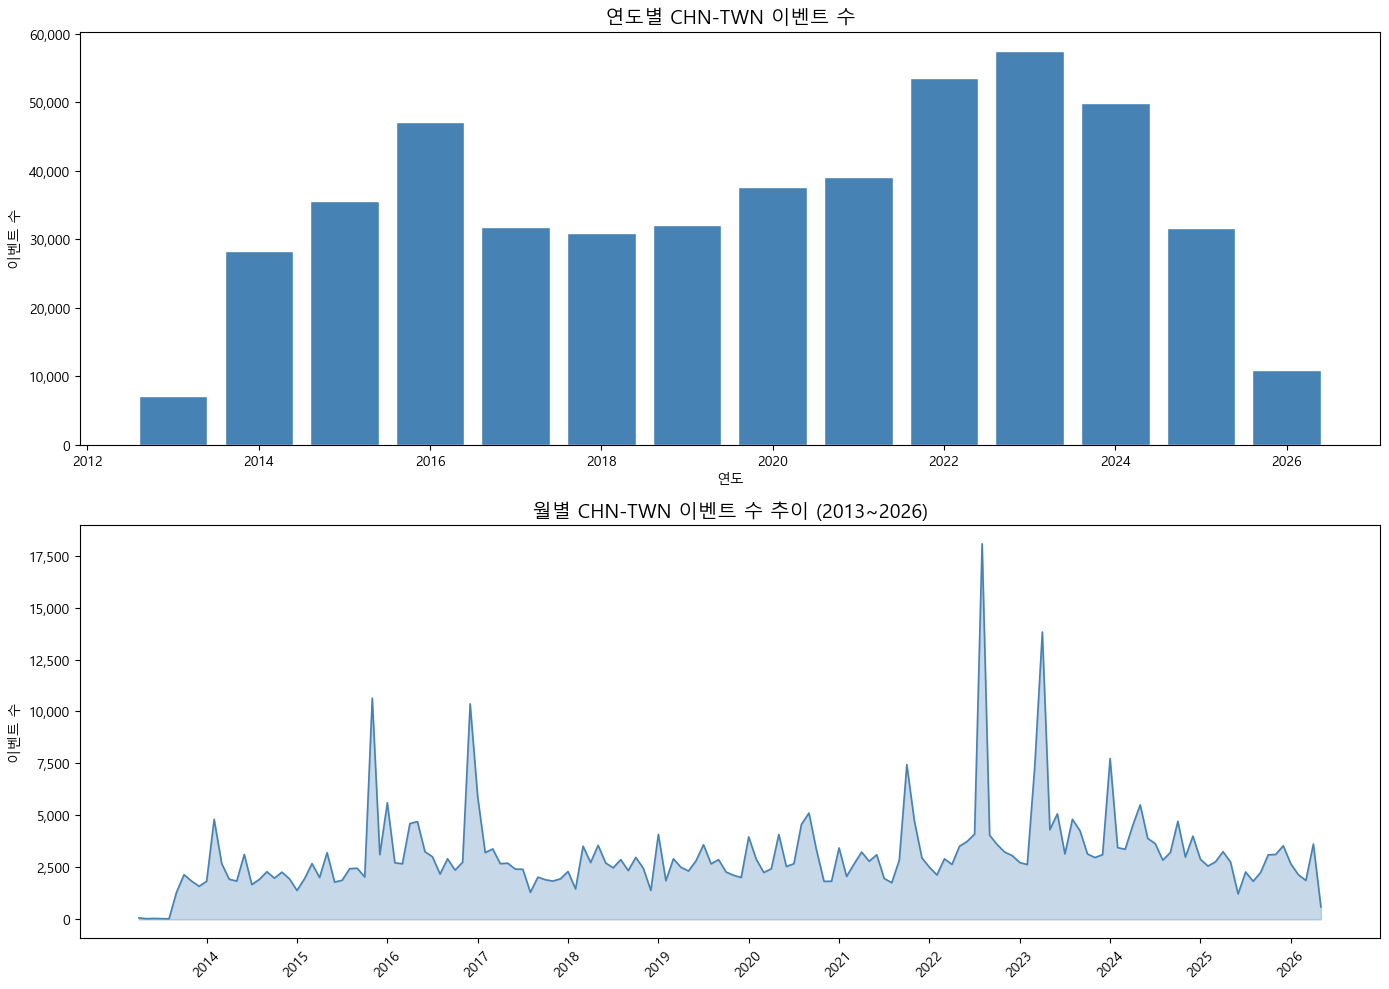

주목할 스파이크 시점을 위 그래프에서 확인하세요.


In [7]:
# # SQLDATE를 datetime으로 변환
# df['date'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')
# df['year'] = df['date'].dt.year
# df['month'] = df['date'].dt.month
# df['yearmonth'] = df['date'].dt.to_period('M')

# ── 2-1. 연도별 이벤트 수 ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

yearly = df.groupby('year').size().reset_index(name='count')
axes[0].bar(yearly['year'], yearly['count'], color='steelblue', edgecolor='white')
axes[0].set_title('연도별 CHN-TWN 이벤트 수', fontsize=14)
axes[0].set_xlabel('연도')
axes[0].set_ylabel('이벤트 수')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── 2-2. 월별 이벤트 수 (시계열) ────────────────────────────
monthly = df.groupby('yearmonth').size().reset_index(name='count')
monthly['yearmonth_str'] = monthly['yearmonth'].astype(str)

axes[1].plot(range(len(monthly)), monthly['count'],
             color='steelblue', linewidth=1.2)
axes[1].fill_between(range(len(monthly)), monthly['count'],
                     alpha=0.3, color='steelblue')
axes[1].set_title('월별 CHN-TWN 이벤트 수 추이 (2013~2026)', fontsize=14)
axes[1].set_ylabel('이벤트 수')

# X축 레이블: 연도만 표시
year_ticks = monthly[monthly['yearmonth_str'].str.endswith('01')].index.tolist()
axes[1].set_xticks(year_ticks)
axes[1].set_xticklabels(
    [s[:4] for s in monthly.loc[year_ticks, 'yearmonth_str']],
    rotation=45
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig("data/eda_timeseries.png", dpi=150, bbox_inches='tight')
plt.show()
print("주목할 스파이크 시점을 위 그래프에서 확인하세요.")

#### Phase 2 시계열 분석 해석
##### 📊 양안관계 주요 이벤트 스파이크 현황 (월별 그래프 기준)

| 시점 (월별 그래프 기준) | 주요 이벤트 내용 | 이벤트 규모 (추정) |
| :--- | :--- | :--- |
| **2016년 초** | 대만 총통 선거 (차이잉원 당선) | ~10,000 |
| **2016년 말** | 트럼프 당선 후 차이-트럼프 통화 사건 | ~10,000 |
| **2022년 8월** | **펠로시 대만 방문 → 중국 대규모 군사훈련** | **~17,500 (역대 최대)** |
| **2023년 4월** | 차이잉원-매카시 회담 → 중국 군사훈련 | ~13,500 |
| **2024년 초** | 대만 총통 선거 (라이칭더 당선) | ~7,500 |


##### - 구조적 패턴 3가지
① 2013~2021: 베이스라인 구간

월평균 약 2,000~3,000건 수준으로 안정적
간헐적 스파이크는 있으나 빠르게 회귀

② 2022~2023: 고긴장 구간

전체 기간 중 가장 큰 스파이크 2개 집중
베이스라인 자체가 상승 (약 3,000~5,000건)
위성 촬영 수요가 가장 높았던 시기

③ 2024~2026: 안정화 구간

이벤트 수 감소 추세
2026년은 4월까지만 수집되어 낮게 보임

#### 일별 기사량 분포

In [ ]:
# 일별 기사량 분포 확인 코드

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_parquet("data/raw/gdelt_chn_twn_2013_2026.parquet")
df['date'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')
df = df.dropna(subset=['GoldsteinScale'])

# ── 집계 단위별 이벤트 수 계산 ───────────────────────────────
daily   = df.groupby('date').size().reset_index(name='count')
weekly  = df.groupby(df['date'].dt.to_period('W')).size().reset_index(name='count')
monthly = df.groupby(df['date'].dt.to_period('M')).size().reset_index(name='count')

# ── 기술 통계 비교 ───────────────────────────────────────────
print("=== 집계 단위별 기술 통계 ===")
for name, data in [('일별', daily), ('주별', weekly), ('월별', monthly)]:
    s = data['count']
    print(f"\n[ {name} ]")
    print(f"  평균   : {s.mean():,.1f}")
    print(f"  표준편차: {s.std():,.1f}")
    print(f"  중앙값 : {s.median():,.1f}")
    print(f"  최솟값 : {s.min():,}")
    print(f"  최댓값 : {s.max():,}")
    print(f"  1σ 임계값: {s.mean()+s.std():,.1f}")
    print(f"  2σ 임계값: {s.mean()+2*s.std():,.1f}")
    print(f"  3σ 임계값: {s.mean()+3*s.std():,.1f}")

=== 집계 단위별 기술 통계 ===

[ 일별 ]
  평균   : 105.9
  표준편차: 110.3
  중앙값 : 81.0
  최솟값 : 1
  최댓값 : 1,917
  1σ 임계값: 216.2
  2σ 임계값: 326.5
  3σ 임계값: 436.8

[ 주별 ]
  평균   : 724.2
  표준편차: 638.9
  중앙값 : 599.0
  최솟값 : 1
  최댓값 : 8,985
  1σ 임계값: 1,363.1
  2σ 임계값: 2,002.0
  3σ 임계값: 2,640.8

[ 월별 ]
  평균   : 3,136.6
  표준편차: 2,104.2
  중앙값 : 2,737.0
  최솟값 : 32
  최댓값 : 18,068
  1σ 임계값: 5,240.8
  2σ 임계값: 7,345.0
  3σ 임계값: 9,449.3


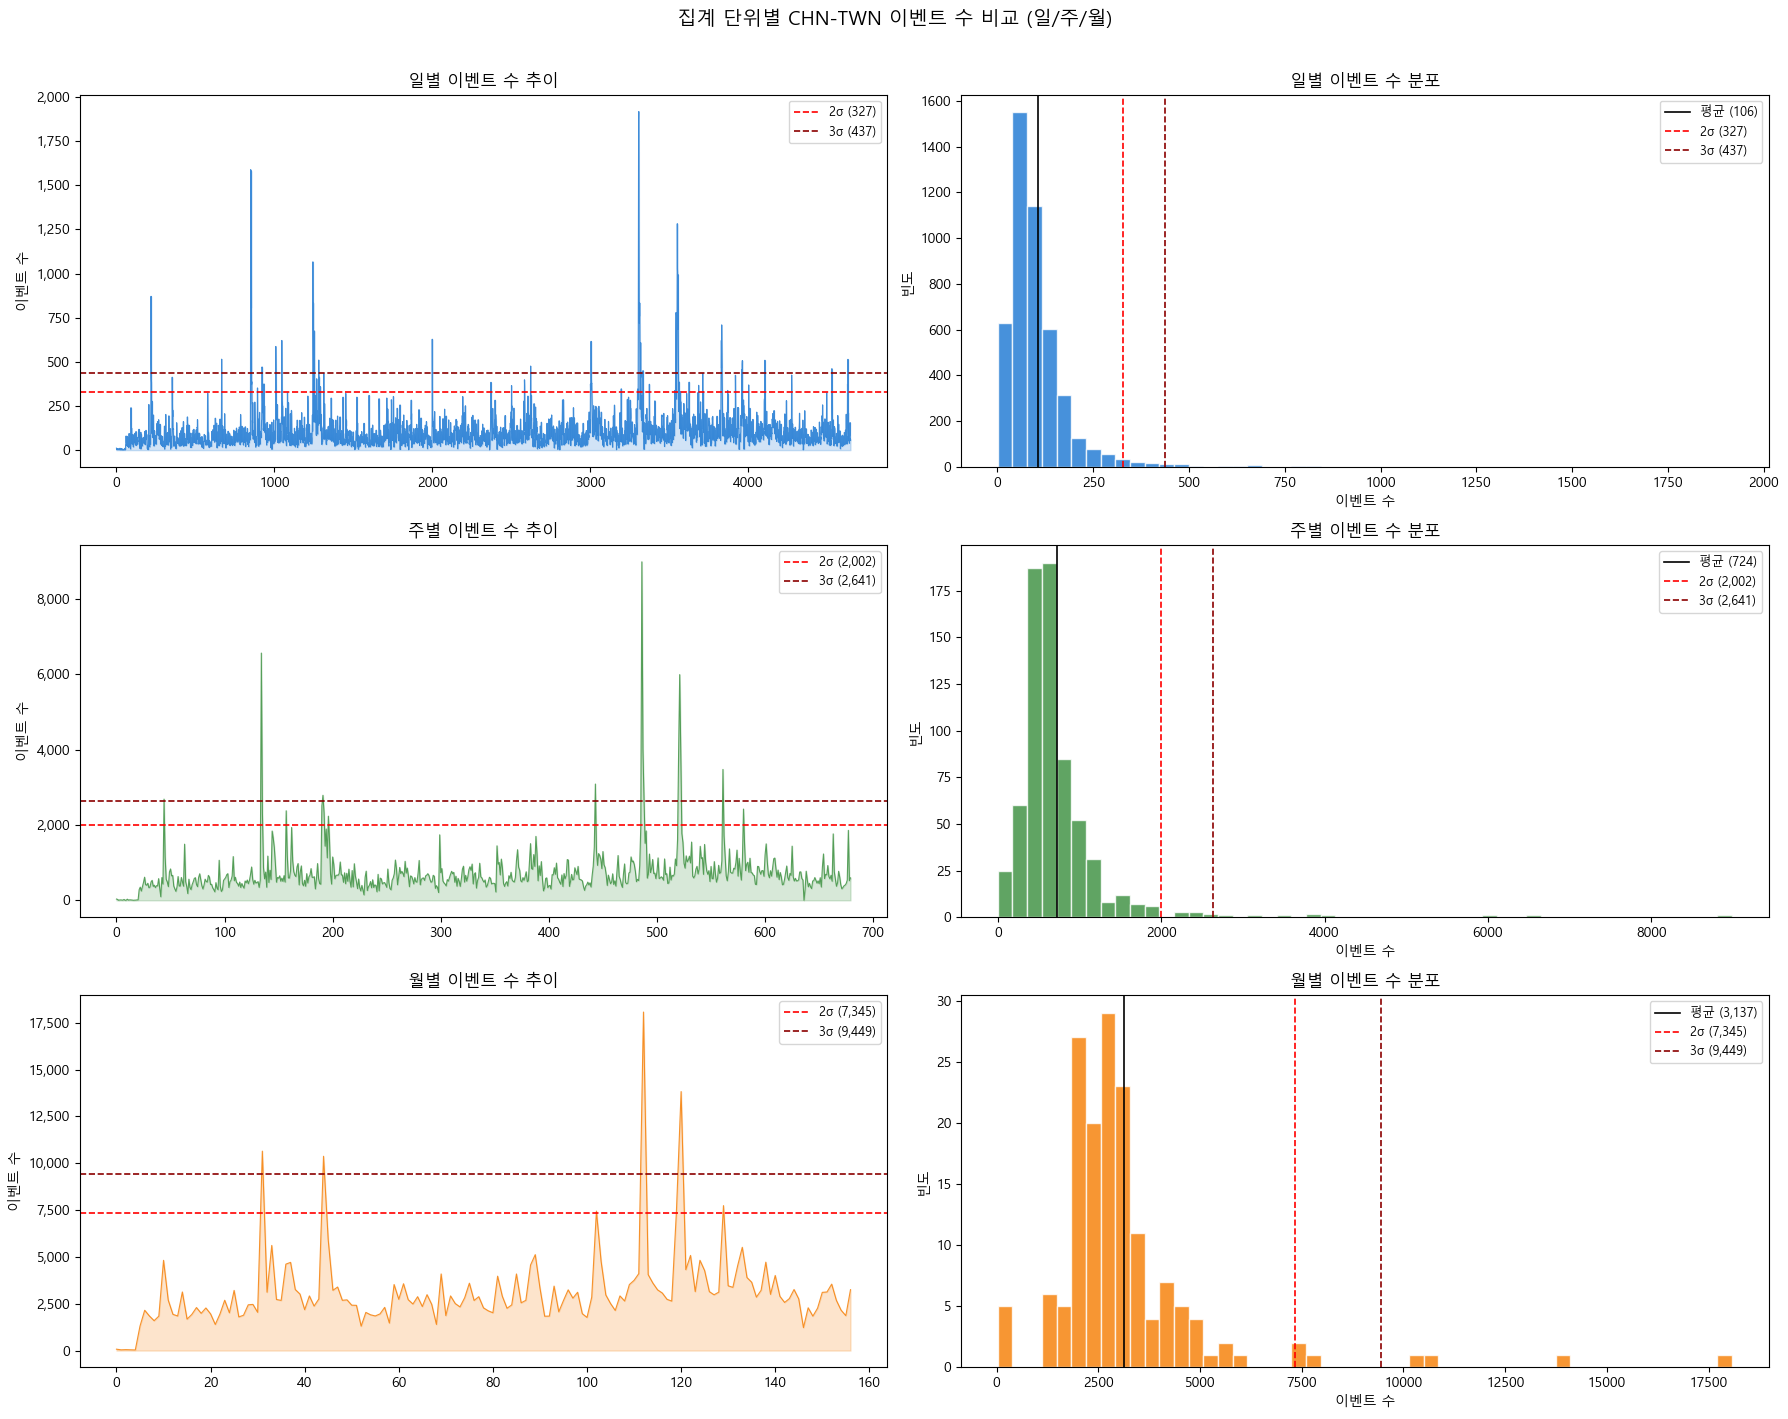

In [ ]:
# ── 시각화: 3개 단위 동시 비교 ──────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(18, 14))

units = [
    ('일별',  daily,   'date',  '#1976d2'),
    ('주별',  weekly,  'date',  '#388e3c'),
    ('월별',  monthly, 'date',  '#f57c00'),
]

for i, (name, data, col, color) in enumerate(units):
    x = range(len(data))
    s = data['count']
    mean, std = s.mean(), s.std()

    # 왼쪽: 시계열
    axes[i,0].plot(x, s.values, color=color, linewidth=0.8, alpha=0.8)
    axes[i,0].fill_between(x, s.values, alpha=0.2, color=color)
    axes[i,0].axhline(mean + 2*std, color='red',
                      linestyle='--', linewidth=1.2,
                      label=f'2σ ({mean+2*std:,.0f})')
    axes[i,0].axhline(mean + 3*std, color='darkred',
                      linestyle='--', linewidth=1.2,
                      label=f'3σ ({mean+3*std:,.0f})')
    axes[i,0].set_title(f'{name} 이벤트 수 추이', fontsize=12)
    axes[i,0].set_ylabel('이벤트 수')
    axes[i,0].legend(fontsize=9)
    axes[i,0].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

    # 오른쪽: 분포 히스토그램
    axes[i,1].hist(s.values, bins=50, color=color,
                   edgecolor='white', alpha=0.8)
    axes[i,1].axvline(mean, color='black', linestyle='-',
                      linewidth=1.2, label=f'평균 ({mean:,.0f})')
    axes[i,1].axvline(mean+2*std, color='red', linestyle='--',
                      linewidth=1.2, label=f'2σ ({mean+2*std:,.0f})')
    axes[i,1].axvline(mean+3*std, color='darkred', linestyle='--',
                      linewidth=1.2, label=f'3σ ({mean+3*std:,.0f})')
    axes[i,1].set_title(f'{name} 이벤트 수 분포', fontsize=12)
    axes[i,1].set_xlabel('이벤트 수')
    axes[i,1].set_ylabel('빈도')
    axes[i,1].legend(fontsize=9)

plt.suptitle('집계 단위별 CHN-TWN 이벤트 수 비교 (일/주/월)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("data/eda_granularity_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 단위별 스파이크 탐지 민감도 비교 ────────────────────────
print("\n=== 단위별 스파이크 탐지 민감도 비교 ===")
print(f"{'단위':<6} {'전체기간':>8} {'2σ초과':>8} {'3σ초과':>8} {'비율(2σ%)':>10}")
print("-" * 45)

for name, data in [('일별', daily), ('주별', weekly), ('월별', monthly)]:
    s = data['count']
    mean, std = s.mean(), s.std()
    total  = len(s)
    over2  = (s >= mean + 2*std).sum()
    over3  = (s >= mean + 3*std).sum()
    ratio  = over2 / total * 100
    print(f"{name:<6} {total:>8,} {over2:>8} {over3:>8} {ratio:>9.1f}%")


=== 단위별 스파이크 탐지 민감도 비교 ===
단위         전체기간     2σ초과     3σ초과    비율(2σ%)
---------------------------------------------
일별        4,650      125       70       2.7%
주별          680       17       11       2.5%
월별          157        7        4       4.5%


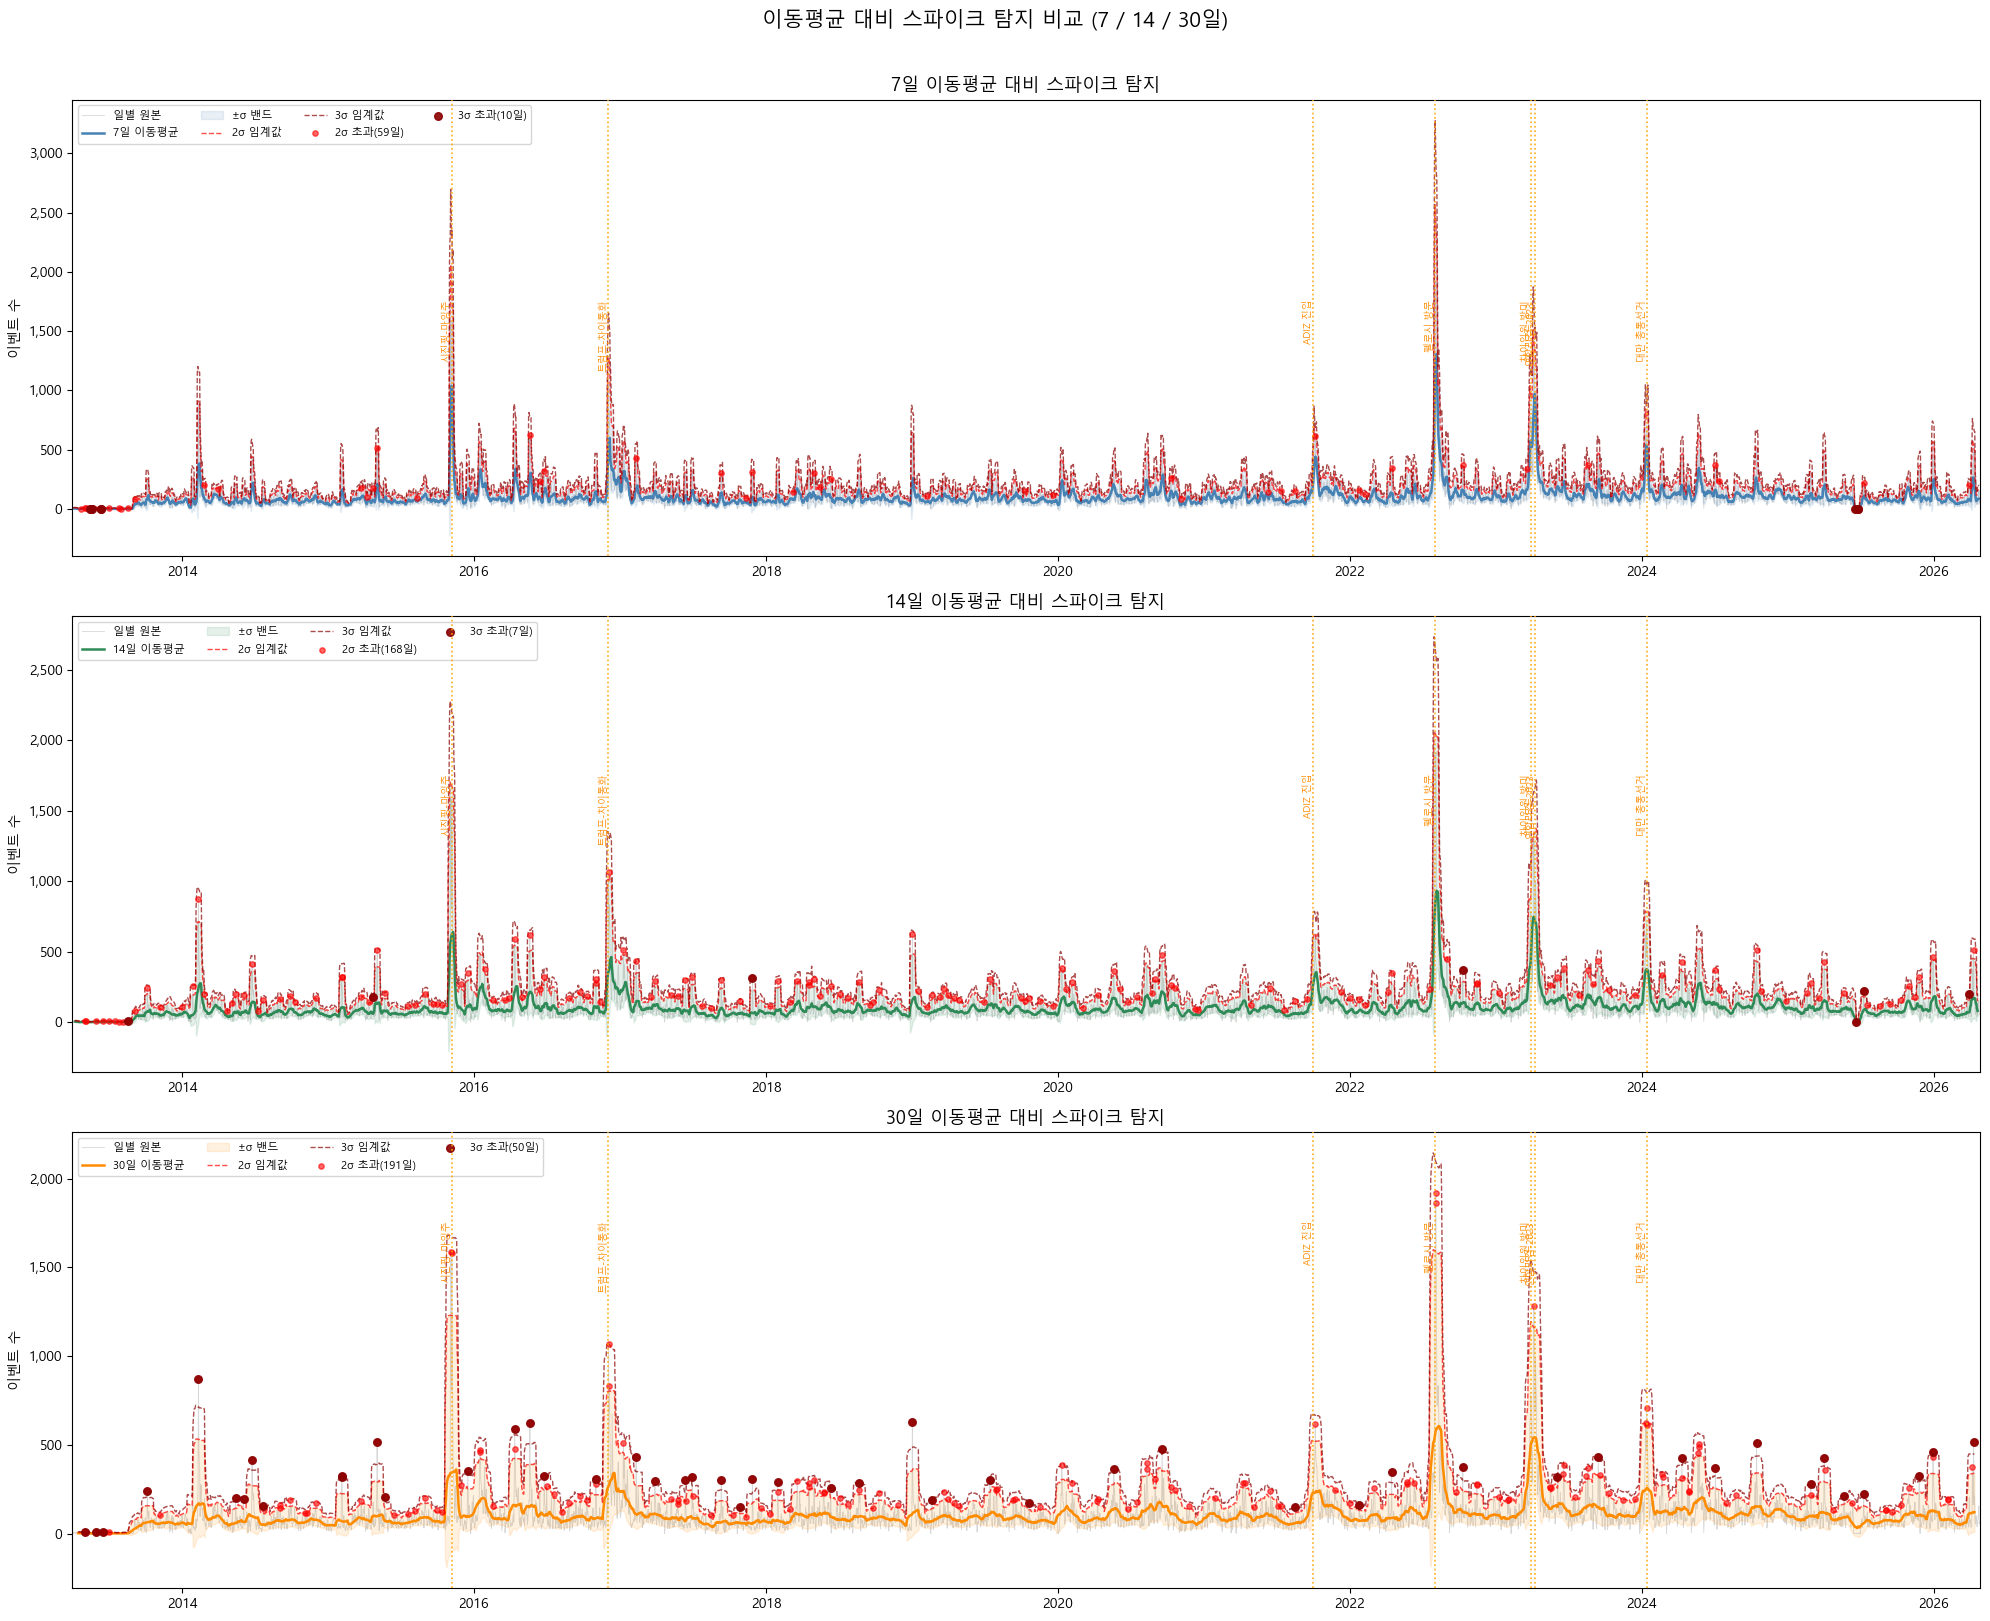

=== 이동평균 기반 스파이크 탐지 요약 ===

기간        2σ초과일    3σ초과일     탐지율%
-----------------------------------
7일          59       10     1.2%
14일         168        7     3.5%
30일         191       50     4.0%

=== 실제 사건 전후 7일 내 스파이크 탐지 여부 ===

사건                        7일창       14일창       30일창
----------------------------------------------------
펠로시 방문                   ❌미탐지      ❌미탐지      ✅2일후
연합리검-2023                ❌미탐지      ❌미탐지      ❌미탐지
시진핑-마잉주                  ❌미탐지      ❌미탐지      ✅0일후
트럼프-차이통화                 ❌미탐지      ✅1일후      ✅1일후
대만 총통선거                  ❌미탐지      ❌미탐지      ✅0일후
ADIZ 진입                  ✅5일후      ❌미탐지      ✅5일후
차이잉원 방미                  ❌미탐지      ❌미탐지      ✅8일후


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_parquet("data/raw/gdelt_chn_twn_2013_2026.parquet")
df['date'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')
df = df.dropna(subset=['GoldsteinScale'])

daily = df.groupby('date').size().reset_index(name='count')
daily = daily.set_index('date').asfreq('D', fill_value=0).reset_index()

# 알려진 실제 사건
known_events = {
    '펠로시 방문':     '2022-08-02',
    '연합리검-2023':   '2023-04-08',
    '시진핑-마잉주':   '2015-11-07',
    '트럼프-차이통화': '2016-12-02',
    '대만 총통선거':   '2024-01-13',
    'ADIZ 진입':       '2021-10-01',
    '차이잉원 방미':   '2023-03-29',
}

# ── 이동평균 및 임계값 계산 ──────────────────────────────────
for w in [7, 14, 30]:
    daily[f'ma_{w}']        = daily['count'].rolling(w, center=True).mean()
    daily[f'std_{w}']       = daily['count'].rolling(w, center=True).std()
    daily[f'upper2s_{w}']   = daily[f'ma_{w}'] + 2 * daily[f'std_{w}']
    daily[f'upper3s_{w}']   = daily[f'ma_{w}'] + 3 * daily[f'std_{w}']
    daily[f'spike2s_{w}']   = daily['count'] >= daily[f'upper2s_{w}']
    daily[f'spike3s_{w}']   = daily['count'] >= daily[f'upper3s_{w}']

# ── 시각화 ───────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(20, 16))

colors = {7: 'steelblue', 14: 'seagreen', 30: 'darkorange'}

for i, window in enumerate([7, 14, 30]):
    ax = axes[i]
    c  = colors[window]

    # 원본 데이터
    ax.plot(daily['date'], daily['count'],
            color='lightgrey', linewidth=0.6,
            alpha=0.9, label='일별 원본', zorder=1)

    # 이동평균선
    ax.plot(daily['date'], daily[f'ma_{window}'],
            color=c, linewidth=1.8,
            label=f'{window}일 이동평균', zorder=2)

    # 2σ 밴드
    ax.fill_between(daily['date'],
                    daily[f'ma_{window}'] - daily[f'std_{window}'],
                    daily[f'ma_{window}'] + 2 * daily[f'std_{window}'],
                    alpha=0.12, color=c, label=f'±σ 밴드')

    # 2σ / 3σ 임계선
    ax.plot(daily['date'], daily[f'upper2s_{window}'],
            color='red', linewidth=1.0,
            linestyle='--', alpha=0.7, label=f'2σ 임계값', zorder=3)
    ax.plot(daily['date'], daily[f'upper3s_{window}'],
            color='darkred', linewidth=1.0,
            linestyle='--', alpha=0.7, label=f'3σ 임계값', zorder=3)

    # 2σ 초과 스파이크 포인트
    spike2 = daily[daily[f'spike2s_{window}']]
    spike3 = daily[daily[f'spike3s_{window}']]

    ax.scatter(spike2['date'], spike2['count'],
               color='red', s=15, zorder=4,
               alpha=0.6, label=f'2σ 초과({len(spike2)}일)')
    ax.scatter(spike3['date'], spike3['count'],
               color='darkred', s=30, zorder=5,
               alpha=0.9, label=f'3σ 초과({len(spike3)}일)')

    # 실제 사건 수직선
    y_max = daily['count'].max()
    for event_name, event_date in known_events.items():
        ax.axvline(pd.Timestamp(event_date),
                   color='orange', linewidth=1.2,
                   linestyle=':', alpha=0.9, zorder=6)
        ax.text(pd.Timestamp(event_date),
                y_max * 0.92,
                event_name,
                fontsize=7, color='darkorange',
                rotation=90, va='top', ha='right')

    ax.set_title(f'{window}일 이동평균 대비 스파이크 탐지', fontsize=13)
    ax.set_ylabel('이벤트 수')
    ax.legend(loc='upper left', fontsize=8, ncol=4)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
    ax.set_xlim(daily['date'].min(), daily['date'].max())

plt.suptitle('이동평균 대비 스파이크 탐지 비교 (7 / 14 / 30일)',
             fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("data/eda_moving_average_spike.png", dpi=150, bbox_inches='tight')
plt.show()

# ── 수치 요약 ────────────────────────────────────────────────
print("=== 이동평균 기반 스파이크 탐지 요약 ===\n")
print(f"{'기간':<6} {'2σ초과일':>8} {'3σ초과일':>8} {'탐지율%':>8}")
print("-" * 35)
for window in [7, 14, 30]:
    s2 = daily[f'spike2s_{window}'].sum()
    s3 = daily[f'spike3s_{window}'].sum()
    rate = s2 / len(daily) * 100
    print(f"{window}일{'':<3} {s2:>8} {s3:>8} {rate:>7.1f}%")

# ── 실제 사건별 탐지 여부 확인 ──────────────────────────────
print("\n=== 실제 사건 전후 7일 내 스파이크 탐지 여부 ===\n")
print(f"{'사건':<18} {'7일창':>10} {'14일창':>10} {'30일창':>10}")
print("-" * 52)

for event_name, event_date in known_events.items():
    event_dt = pd.Timestamp(event_date)
    row = []

    for window in [7, 14, 30]:
        mask = (
            (daily['date'] >= event_dt) &
            (daily['date'] <= event_dt + pd.Timedelta(days=window))
        )
        window_data = daily[mask]
        detected = window_data[f'spike2s_{window}'].any()
        peak_day  = (window_data.loc[
            window_data['count'].idxmax(), 'date'
        ] - event_dt).days if len(window_data) > 0 else -1

        result = f"✅{peak_day}일후" if detected else "❌미탐지"
        row.append(f"{result:>10}")

    print(f"{event_name:<18} {''.join(row)}")

### 14일, 30일 이중 탐지 구조 검증

In [ ]:
# 이중 탐지 구조 검증 코드

print("=== 14일 OR 30일 이중 탐지 구조 검증 ===\n")
print(f"{'사건':<18} {'14일':>8} {'30일':>8} {'이중탐지':>10} {'최초탐지':>10}")
print("-" * 58)

for event_name, event_date in known_events.items():
    event_dt = pd.Timestamp(event_date)
    detections = []

    for window in [14, 30]:
        mask = (
            (daily['date'] >= event_dt) &
            (daily['date'] <= event_dt + pd.Timedelta(days=window))
        )
        window_data = daily[mask]
        detected = window_data[f'spike2s_{window}'].any()

        if detected:
            spike_days = window_data[window_data[f'spike2s_{window}']]
            first_day  = (spike_days['date'].min() - event_dt).days
            detections.append(first_day)
        else:
            detections.append(None)

    d14, d30 = detections
    dual     = d14 is not None or d30 is not None
    earliest = min([d for d in [d14, d30] if d is not None], default=None)

    d14_str  = f"✅{d14}일후" if d14 is not None else "❌"
    d30_str  = f"✅{d30}일후" if d30 is not None else "❌"
    dual_str = "✅탐지" if dual else "❌미탐지"
    early_str= f"{earliest}일후" if earliest is not None else "미탐지"

    print(f"{event_name:<18} {d14_str:>8} {d30_str:>8} "
          f"{dual_str:>10} {early_str:>10}")

# 연합리검 기준일 보정 테스트
print("\n=== 연합리검-2023 기준일 보정 테스트 ===")
test_dates = {
    '04-05(훈련예고)': '2023-04-05',
    '04-06(압박시작)': '2023-04-06',
    '04-08(원래기준)': '2023-04-08',
    '04-10(훈련절정)': '2023-04-10',
}
for label, date in test_dates.items():
    event_dt = pd.Timestamp(date)
    for window in [14, 30]:
        mask = (
            (daily['date'] >= event_dt) &
            (daily['date'] <= event_dt + pd.Timedelta(days=window))
        )
        window_data = daily[mask]
        detected    = window_data[f'spike2s_{window}'].any()
        result      = "✅" if detected else "❌"
        print(f"  {label} | {window}일창: {result}")

=== 14일 OR 30일 이중 탐지 구조 검증 ===

사건                      14일      30일       이중탐지       최초탐지
----------------------------------------------------------
펠로시 방문                    ❌     ✅1일후        ✅탐지        1일후
연합리검-2023                 ❌        ❌       ❌미탐지        미탐지
시진핑-마잉주                   ❌     ✅0일후        ✅탐지        0일후
트럼프-차이통화               ✅1일후     ✅1일후        ✅탐지        1일후
대만 총통선거                   ❌     ✅0일후        ✅탐지        0일후
ADIZ 진입                   ❌     ✅5일후        ✅탐지        5일후
차이잉원 방미                   ❌     ✅8일후        ✅탐지        8일후

=== 연합리검-2023 기준일 보정 테스트 ===
  04-05(훈련예고) | 14일창: ❌
  04-05(훈련예고) | 30일창: ✅
  04-06(압박시작) | 14일창: ❌
  04-06(압박시작) | 30일창: ✅
  04-08(원래기준) | 14일창: ❌
  04-08(원래기준) | 30일창: ❌
  04-10(훈련절정) | 14일창: ❌
  04-10(훈련절정) | 30일창: ❌


=== 임계값별 탐지 성능 비교 ===

구분                       2σ(현재)     1.5σ(완화)
---------------------------------------------
14일 탐지일수          168일(3.5%)    369일(7.7%)
30일 탐지일수          191일(4.0%)    357일(7.5%)

사건                   14일_2σ   14일_1.5σ   30일_2σ   30일_1.5σ       최선
--------------------------------------------------------------------
펠로시 방문                    ❌       ✅1일후     ✅1일후       ✅0일후      0일후
연합리검-2023                 ❌       ✅1일후     ✅1일후       ✅1일후      1일후
시진핑-마잉주                   ❌       ✅0일후     ✅0일후       ✅0일후      0일후
트럼프-차이통화               ✅1일후       ✅1일후     ✅1일후       ✅1일후      1일후
대만 총통선거                   ❌       ✅0일후     ✅0일후       ✅0일후      0일후
ADIZ 진입                   ❌       ✅5일후     ✅5일후       ✅5일후      5일후
차이잉원 방미                   ❌       ✅0일후     ✅8일후       ✅8일후      0일후


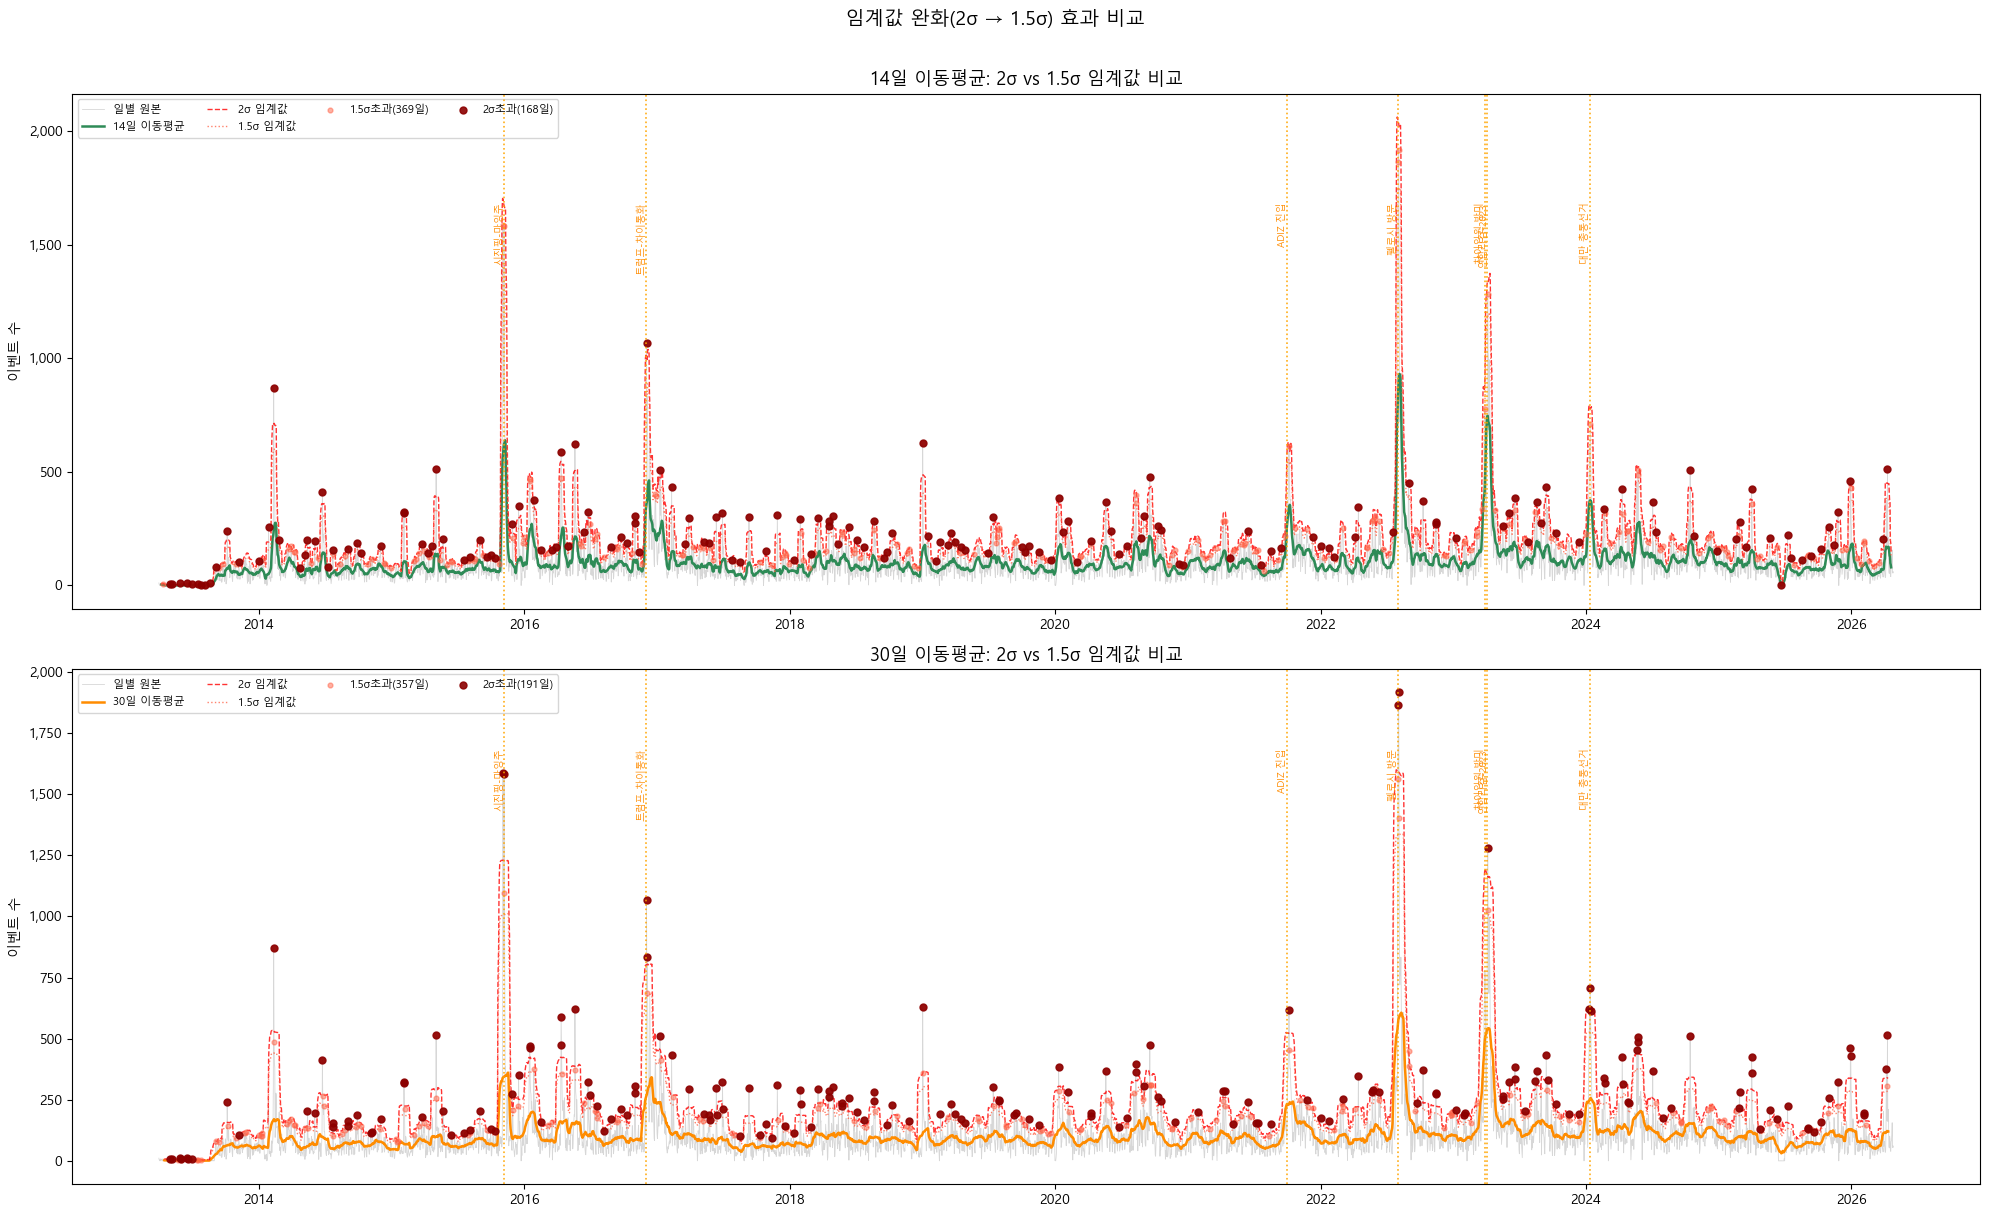

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 1.5σ 임계값 추가 테스트 ──────────────────────────────────
for w in [14, 30]:
    daily[f'spike1_5s_{w}'] = (
        daily['count'] >= daily[f'ma_{w}'] + 1.5 * daily[f'std_{w}']
    )

known_events = {
    '펠로시 방문':     '2022-08-02',
    '연합리검-2023':   '2023-04-05',   # 기준일 보정
    '시진핑-마잉주':   '2015-11-07',
    '트럼프-차이통화': '2016-12-02',
    '대만 총통선거':   '2024-01-13',
    'ADIZ 진입':       '2021-10-01',
    '차이잉원 방미':   '2023-03-29',
}

print("=== 임계값별 탐지 성능 비교 ===\n")
print(f"{'구분':<20} {'2σ(현재)':>10} {'1.5σ(완화)':>12}")
print("-" * 45)

for window in [14, 30]:
    cnt_2s   = daily[f'spike2s_{window}'].sum()
    cnt_1_5s = daily[f'spike1_5s_{window}'].sum()
    rate_2s   = cnt_2s   / len(daily) * 100
    rate_1_5s = cnt_1_5s / len(daily) * 100
    print(f"{window}일 탐지일수{'':<6} "
          f"{cnt_2s:>6}일({rate_2s:.1f}%) "
          f"{cnt_1_5s:>6}일({rate_1_5s:.1f}%)")

print()
print(f"{'사건':<18} {'14일_2σ':>8} {'14일_1.5σ':>10} "
      f"{'30일_2σ':>8} {'30일_1.5σ':>10} {'최선':>8}")
print("-" * 68)

final_results = []
for event_name, event_date in known_events.items():
    event_dt = pd.Timestamp(event_date)
    row = {'사건': event_name}
    timings = []

    for window in [14, 30]:
        for sigma, col in [('2σ', f'spike2s_{window}'),
                           ('1.5σ', f'spike1_5s_{window}')]:
            mask = (
                (daily['date'] >= event_dt) &
                (daily['date'] <= event_dt + pd.Timedelta(days=window))
            )
            wd = daily[mask]
            detected = wd[col].any()

            if detected:
                first = (wd[wd[col]]['date'].min() - event_dt).days
                timings.append(first)
                row[f'{window}일_{sigma}'] = f"✅{first}일후"
            else:
                row[f'{window}일_{sigma}'] = "❌"

    row['최선'] = f"{min(timings)}일후" if timings else "미탐지"
    final_results.append(row)

    r = row
    print(f"{r['사건']:<18} "
          f"{r.get('14일_2σ','❌'):>8} "
          f"{r.get('14일_1.5σ','❌'):>10} "
          f"{r.get('30일_2σ','❌'):>8} "
          f"{r.get('30일_1.5σ','❌'):>10} "
          f"{r['최선']:>8}")

# ── 시각화: 2σ vs 1.5σ 비교 ─────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(20, 12))

for i, window in enumerate([14, 30]):
    ax = axes[i]
    c  = 'seagreen' if window == 14 else 'darkorange'

    ax.plot(daily['date'], daily['count'],
            color='lightgrey', linewidth=0.6, alpha=0.9,
            label='일별 원본', zorder=1)
    ax.plot(daily['date'], daily[f'ma_{window}'],
            color=c, linewidth=1.8,
            label=f'{window}일 이동평균', zorder=2)

    # 1.5σ / 2σ 임계선
    threshold_2s  = daily[f'ma_{window}'] + 2.0 * daily[f'std_{window}']
    threshold_1_5s= daily[f'ma_{window}'] + 1.5 * daily[f'std_{window}']

    ax.plot(daily['date'], threshold_2s,
            color='red', linewidth=1.0, linestyle='--',
            alpha=0.8, label='2σ 임계값', zorder=3)
    ax.plot(daily['date'], threshold_1_5s,
            color='tomato', linewidth=1.0, linestyle=':',
            alpha=0.8, label='1.5σ 임계값', zorder=3)

    # 스파이크 포인트
    sp2   = daily[daily[f'spike2s_{window}']]
    sp1_5 = daily[daily[f'spike1_5s_{window}']]

    ax.scatter(sp1_5['date'], sp1_5['count'],
               color='tomato', s=12, alpha=0.5, zorder=4,
               label=f'1.5σ초과({len(sp1_5)}일)')
    ax.scatter(sp2['date'], sp2['count'],
               color='darkred', s=25, alpha=0.9, zorder=5,
               label=f'2σ초과({len(sp2)}일)')

    # 실제 사건 수직선
    y_max = daily['count'].max()
    for event_name, event_date in known_events.items():
        ax.axvline(pd.Timestamp(event_date),
                   color='orange', linewidth=1.2,
                   linestyle=':', alpha=0.9, zorder=6)
        ax.text(pd.Timestamp(event_date),
                y_max * 0.88, event_name,
                fontsize=7, color='darkorange',
                rotation=90, va='top', ha='right')

    ax.set_title(f'{window}일 이동평균: 2σ vs 1.5σ 임계값 비교',
                 fontsize=13)
    ax.set_ylabel('이벤트 수')
    ax.legend(loc='upper left', fontsize=8, ncol=4)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('임계값 완화(2σ → 1.5σ) 효과 비교',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("data/eda_threshold_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

#### + 스파이크 임계값 정량화

=== 스파이크 임계값 ===
월평균       : 3,123건
표준편차     : 2,107건
1σ (주의)    : 5,231건
2σ (스파이크): 7,338건
3σ (심각)    : 9,446건

=== 2σ 이상 스파이크 (7개월) ===
yearmonth  count
  2015-11  10644
  2016-12  10371
  2021-10   7444
  2022-08  18068
  2023-03   7410
  2023-04  13824
  2024-01   7737


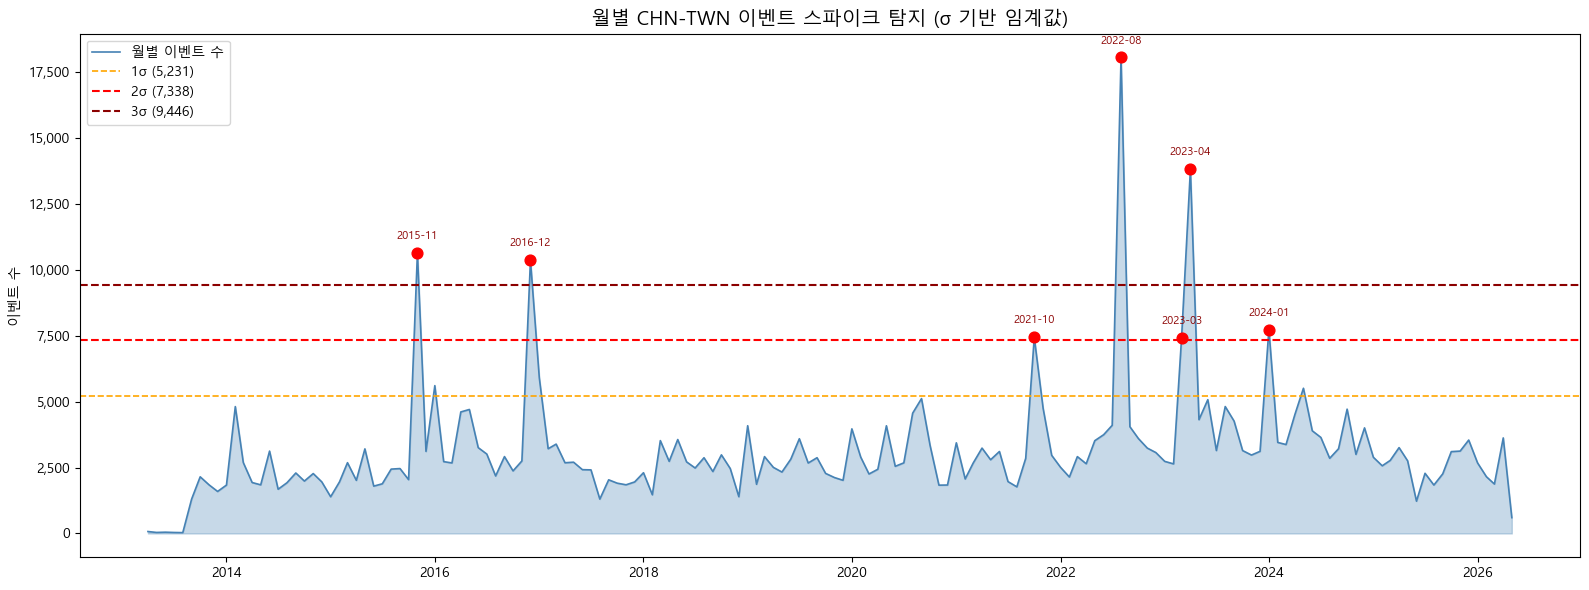

In [8]:
# 월별 데이터 준비
monthly = df.groupby('yearmonth').size().reset_index(name='count')
monthly['yearmonth_dt'] = monthly['yearmonth'].dt.to_timestamp()

# 통계 기반 임계값 계산
mean = monthly['count'].mean()
std  = monthly['count'].std()

threshold_1sigma = mean + 1 * std   # 일반 주의
threshold_2sigma = mean + 2 * std   # 스파이크
threshold_3sigma = mean + 3 * std   # 심각 스파이크

print("=== 스파이크 임계값 ===")
print(f"월평균       : {mean:,.0f}건")
print(f"표준편차     : {std:,.0f}건")
print(f"1σ (주의)    : {threshold_1sigma:,.0f}건")
print(f"2σ (스파이크): {threshold_2sigma:,.0f}건")
print(f"3σ (심각)    : {threshold_3sigma:,.0f}건")
print()

# 스파이크 월 추출
spikes = monthly[monthly['count'] >= threshold_2sigma].copy()
print(f"=== 2σ 이상 스파이크 ({len(spikes)}개월) ===")
print(spikes[['yearmonth', 'count']].to_string(index=False))

# 시각화: 임계값 라인 포함
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(monthly['yearmonth_dt'], monthly['count'],
        color='steelblue', linewidth=1.2, label='월별 이벤트 수')
ax.fill_between(monthly['yearmonth_dt'], monthly['count'],
                alpha=0.3, color='steelblue')

# 임계값 라인
ax.axhline(threshold_1sigma, color='orange', linestyle='--',
           linewidth=1.2, label=f'1σ ({threshold_1sigma:,.0f})')
ax.axhline(threshold_2sigma, color='red', linestyle='--',
           linewidth=1.5, label=f'2σ ({threshold_2sigma:,.0f})')
ax.axhline(threshold_3sigma, color='darkred', linestyle='--',
           linewidth=1.5, label=f'3σ ({threshold_3sigma:,.0f})')

# 스파이크 포인트 표시
ax.scatter(spikes['yearmonth_dt'], spikes['count'],
           color='red', zorder=5, s=60)
for _, row in spikes.iterrows():
    ax.annotate(str(row['yearmonth']),
                xy=(row['yearmonth_dt'], row['count']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8, color='darkred')

ax.set_title('월별 CHN-TWN 이벤트 스파이크 탐지 (σ 기반 임계값)', fontsize=14)
ax.set_ylabel('이벤트 수')
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig("data/eda_spike_detection.png", dpi=150, bbox_inches='tight')
plt.show()

#### 스파이크 탐지 결과 해석
##### 7개 스파이크 시점 × 실제 사건 매핑
### 📊 양안관계 주요 이벤트 및 이상 징후 분석 현황

| 시점 | 이벤트 수 | 등급 | 실제 사건 |
| :--- | :---: | :---: | :--- |
| **2022-08** | 18,068 | 🔴 $3\sigma$ 초과 | 펠로시 하원의장 대만 방문 + 중국 역대 최대 군사훈련 |
| **2023-04** | 13,824 | 🔴 $3\sigma$ 초과 | 차이잉원-매카시 회담 $\rightarrow$ 중국 연합리검-2023 훈련 |
| **2015-11** | 10,644 | 🔴 $3\sigma$ 초과 | 시진핑-마잉주 싱가포르 역사적 첫 정상회담 |
| **2016-12** | 10,371 | 🔴 $3\sigma$ 초과 | 트럼프-차이잉원 전화통화 (하나의 중국 원칙 흔들기) |
| **2024-01** | 7,737 | 🟠 $2\sigma \sim 3\sigma$ | 대만 총통선거 (라이칭더 당선) |
| **2021-10** | 7,444 | 🟠 $2\sigma \sim 3\sigma$ | 중국 전투기 대규모 방공식별구역 진입 (역대 최다) |
| **2023-03** | 7,410 | 🟠 $2\sigma \sim 3\sigma$ | 차이잉원 방미 직전 중국 압박 고조 |


#### - 핵심 인사이트 3가지

① 스파이크는 항상 외부 트리거(방문/선거/훈련)에서 발생

- 자연 발생적 상승이 아닌 특정 정치·군사 이벤트에 정확히 반응
- OSINT → GEOINT 연계의 근거가 됨

② 2022년 이후 구조적 긴장 상승

- 2022-08 이전: 스파이크 후 즉시 베이스라인 복귀
- 2022-08 이후: 베이스라인 자체가 ~3,000건으로 상승 유지
- 위성 상시 감시 필요성이 높아진 구간

③ 스파이크 군집 패턴

- 2015-11 → 2016-12 (13개월 간격)
- 2022-08 → 2023-03 → 2023-04 (연속 발생)
- 한 번 긴장 고조되면 후속 이벤트가 연쇄적으로 따라옴


#### Phase 3로 넘어가기 전 스파이크 구간 저장

In [9]:
# 스파이크 구간 정의 및 저장 (이후 CAMEO 분석에 재사용)
spike_periods = {
    '2015-11': {'label': '시진핑-마잉주 정상회담', 'severity': 3},
    '2016-12': {'label': '트럼프-차이잉원 통화',   'severity': 3},
    '2021-10': {'label': '중국 ADIZ 대규모 진입',  'severity': 2},
    '2022-08': {'label': '펠로시 방문+군사훈련',    'severity': 4},
    '2023-03': {'label': '차이잉원 방미 압박',      'severity': 2},
    '2023-04': {'label': '연합리검-2023 훈련',      'severity': 3},
    '2024-01': {'label': '대만 총통선거',           'severity': 2},
}

import json, os
os.makedirs("data/processed", exist_ok=True)
with open("data/processed/spike_periods.json", "w", encoding="utf-8") as f:
    json.dump(spike_periods, f, ensure_ascii=False, indent=2)

print("스파이크 시점 저장 완료 → data/processed/spike_periods.json")

# 스파이크 구간 데이터 별도 추출
spike_months = list(spike_periods.keys())
df['yearmonth_str'] = df['yearmonth'].astype(str)

df_spikes = df[df['yearmonth_str'].isin(spike_months)].copy()
df_spikes.to_parquet("data/processed/gdelt_spike_events.parquet", index=False)

print(f"스파이크 구간 이벤트 저장 완료: {len(df_spikes):,}건")
print(df_spikes.groupby('yearmonth_str').size().sort_values(ascending=False))

스파이크 시점 저장 완료 → data/processed/spike_periods.json
스파이크 구간 이벤트 저장 완료: 75,498건
yearmonth_str
2022-08    18068
2023-04    13824
2015-11    10644
2016-12    10371
2024-01     7737
2021-10     7444
2023-03     7410
dtype: int64


### Phase 3. CAMEO 코드 분석  :  군사/적대 이벤트 비중 파악

#### Phase 3-A: CAMEO 코드 분포 분석 -> 군사/적대 이벤트 비중
#### Phase 3-B: 스파이크 구간 vs 평시 구간 CAMEO 비교 → "스파이크 때 군사 행동(EventRootCode 15~20)이 얼마나 증가하나?"
#### Phase 3-C: GoldsteinScale × QuadClass 교차 분석 → Priority Score 가중치 설계의 근거 데이터


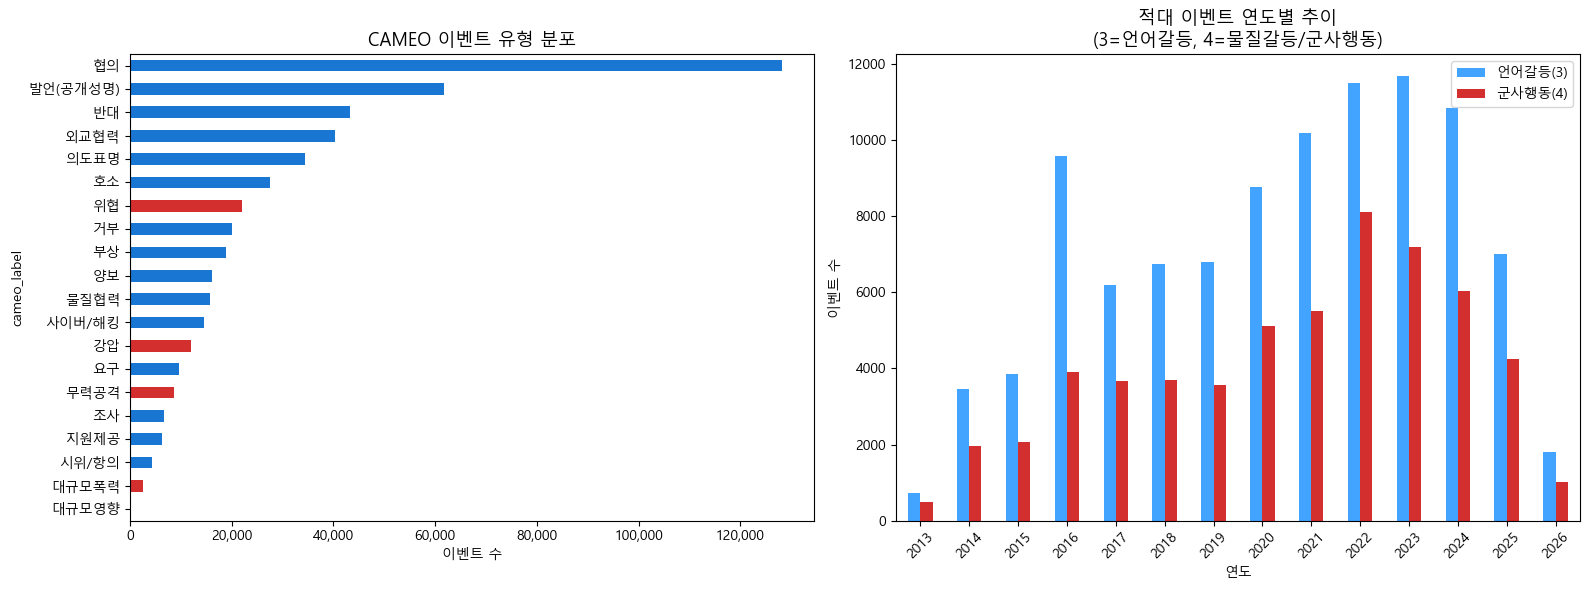

In [ ]:
# # CAMEO EventRootCode 매핑 (프로젝트 핵심 카테고리)
# cameo_root_map = {
#     '01': '발언(공개성명)', '02': '호소', '03': '의도표명',
#     '04': '협의', '05': '외교협력', '06': '물질협력',
#     '07': '지원제공', '08': '양보', '09': '조사',
#     '10': '요구', '11': '반대', '12': '거부',
#     '13': '위협', '14': '시위/항의', '15': '강압',
#     '16': '무력공격', '17': '사이버/해킹', '18': '대규모폭력',
#     '19': '부상', '20': '대규모영향'
# }

# df['EventRootCode_str'] = df['EventRootCode'].astype(str).str.zfill(2)
# df['cameo_label'] = df['EventRootCode_str'].map(cameo_root_map).fillna('기타')

# # ── 3-1. 전체 CAMEO 분포 ────────────────────────────────────
# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# cameo_counts = df['cameo_label'].value_counts()
# colors = ['#d32f2f' if c in ['무력공격','위협','강압','대규모폭력']
#           else '#1976d2' for c in cameo_counts.index]

# cameo_counts.plot(kind='barh', ax=axes[0], color=colors)
# axes[0].set_title('CAMEO 이벤트 유형 분포', fontsize=13)
# axes[0].set_xlabel('이벤트 수')
# axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
# axes[0].invert_yaxis()

# # ── 3-2. 적대 이벤트(QuadClass 3,4)만 연도별 추이 ───────────
# # QuadClass: 1=언어협력, 2=물질협력, 3=언어갈등, 4=물질갈등(군사행동)
# hostile = df[df['QuadClass'].isin([3, 4])]
# hostile_yearly = hostile.groupby(['year', 'QuadClass']).size().unstack(fill_value=0)

# hostile_yearly.plot(kind='bar', ax=axes[1], color=["#43a4ff", '#d32f2f'])
# axes[1].set_title('적대 이벤트 연도별 추이\n(3=언어갈등, 4=물질갈등/군사행동)', fontsize=13)
# axes[1].set_xlabel('연도')
# axes[1].set_ylabel('이벤트 수')
# axes[1].legend(['언어갈등(3)', '군사행동(4)'])
# axes[1].tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.savefig("data/eda_cameo.png", dpi=150, bbox_inches='tight')
# plt.show()

#### Phase 3 — CAMEO 분석 전체 코드

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mticker
# import numpy as np

# plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['axes.unicode_minus'] = False

# # 데이터 로드
# df = pd.read_parquet("data/raw/gdelt_chn_twn_2013_2026.parquet")
# df['date'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')
# df['yearmonth'] = df['date'].dt.to_period('M')
# df['yearmonth_str'] = df['yearmonth'].astype(str)
# df = df.dropna(subset=['GoldsteinScale'])

# df_spikes = pd.read_parquet("data/processed/gdelt_spike_events.parquet")

# # CAMEO RootCode 매핑
# cameo_root_map = {
#     '01': '공개성명', '02': '호소', '03': '의도표명',
#     '04': '협의',    '05': '외교협력', '06': '물질협력',
#     '07': '지원제공', '08': '양보',   '09': '조사',
#     '10': '요구',    '11': '반대',    '12': '거부',
#     '13': '위협',    '14': '시위/항의','15': '군사력과시',
#     '16': '관계축소', '17': '강압', '18': '폭력',
#     '19': '교전',    '20': '대규모폭력'
# }

# # 군사/적대 코드 (위성 촬영 우선순위 직결)
# hostile_codes = ['13', '14', '15', '16', '17', '18', '19', '20']

# for d in [df, df_spikes]:
#     d['RootCode_str'] = d['EventRootCode'].astype(str).str.zfill(2)
#     d['cameo_label']  = d['RootCode_str'].map(cameo_root_map).fillna('기타')
#     d['is_hostile']   = d['RootCode_str'].isin(hostile_codes)

# spike_months = list(df_spikes['yearmonth_str'].unique())
# df_normal = df[~df['yearmonth_str'].isin(spike_months)].copy()

# print(f"스파이크 구간 : {len(df_spikes):,}건")
# print(f"평시 구간     : {len(df_normal):,}건")

스파이크 구간 : 75,498건
평시 구간     : 416,954건


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import json

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 ──────────────────────────────────────────────
df = pd.read_parquet("data/raw/gdelt_chn_twn_2013_2026.parquet")
df['date'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')
df['yearmonth_str'] = df['date'].dt.to_period('M').astype(str)
df = df.dropna(subset=['GoldsteinScale'])

# ── 수정된 CAMEO 맵핑 ────────────────────────────────────────
cameo_root_map = {
    '01': '공개성명', '02': '호소',    '03': '의도표명',
    '04': '협의',    '05': '외교협력', '06': '물질협력',
    '07': '지원제공', '08': '양보',    '09': '조사',
    '10': '요구',    '11': '반대',    '12': '거부',
    '13': '위협',    '14': '시위/항의','15': '군사력과시',
    '16': '관계축소', '17': '강압',   '18': '폭력',
    '19': '교전',    '20': '대규모폭력'
}

# ── 수정된 위성 관련 코드 ────────────────────────────────────
satellite_relevant = {
    '13': True,   # 위협        → 군사 이동 예고
    '14': False,  # 시위/항의   → 민간 행동
    '15': True,   # 군사력과시  → 군사 이동 직접
    '16': False,  # 관계축소    → 외교 행위
    '17': True,   # 강압        → 봉쇄/집결
    '18': True,   # 폭력        → 실제 충돌
    '19': True,   # 교전        → 직접 전투
    '20': True,   # 대규모폭력  → 최고 위험
}

spike_months = ['2015-11','2016-12','2021-10',
                '2022-08','2023-03','2023-04','2024-01']

df['RootCode_str'] = df['EventRootCode'].astype(str).str.zfill(2)
df['cameo_label']  = df['RootCode_str'].map(cameo_root_map).fillna('기타')
df['is_spike']     = df['yearmonth_str'].isin(spike_months)
df['is_satellite'] = df['RootCode_str'].map(satellite_relevant).fillna(False)

df_spikes = df[df['is_spike']].copy()
df_normal = df[~df['is_spike']].copy()

spike_total  = len(df_spikes)
normal_total = len(df_normal)

print(f"스파이크 구간: {spike_total:,}건")
print(f"평시 구간   : {normal_total:,}건")

스파이크 구간: 75,498건
평시 구간   : 417,944건


### CAMEO 분류에서 hostile_codes 선택 기준 통계적으로 확인하기

In [ ]:
# CAMEO 분류에서 hostile_codes 선택 기준 통계적으로 확인하기
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 준비 ──────────────────────────────────────────────
df = pd.read_parquet("data/raw/gdelt_chn_twn_2013_2026.parquet")
df['date'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')
df['yearmonth_str'] = df['date'].dt.to_period('M').astype(str)
df = df.dropna(subset=['GoldsteinScale'])

cameo_root_map = {
    '01': '공개성명', '02': '호소',    '03': '의도표명',
    '04': '협의',    '05': '외교협력', '06': '물질협력',
    '07': '지원제공', '08': '양보',    '09': '조사',
    '10': '요구',    '11': '반대',    '12': '거부',
    '13': '위협',    '14': '시위/항의','15': '군사력과시',
    '16': '관계축소', '17': '강압',   '18': '폭력',
    '19': '교전',    '20': '대규모폭력'
}

spike_months = ['2015-11','2016-12','2021-10',
                '2022-08','2023-03','2023-04','2024-01']

df['RootCode_str'] = df['EventRootCode'].astype(str).str.zfill(2)
df['cameo_label']  = df['RootCode_str'].map(cameo_root_map).fillna('기타')
df['is_spike']     = df['yearmonth_str'].isin(spike_months)

spike_total  = df['is_spike'].sum()
normal_total = (~df['is_spike']).sum()

print(f"스파이크 구간: {spike_total:,}건")
print(f"평시 구간   : {normal_total:,}건")

# ── Step 1+2: 카이제곱 + 증감률 계산 ────────────────────────
results = []

for code, label in cameo_root_map.items():

    spike_count  = ((df['RootCode_str']==code) &  df['is_spike']).sum()
    normal_count = ((df['RootCode_str']==code) & ~df['is_spike']).sum()
    total_code   = spike_count + normal_count

    # 기대빈도 (너무 적으면 검정 불가)
    exp_spike  = spike_total  * total_code / (spike_total + normal_total)
    exp_normal = normal_total * total_code / (spike_total + normal_total)

    if exp_spike < 5 or exp_normal < 5:
        continue

    # 카이제곱 검정
    chi2, p_val = stats.chisquare(
        f_obs=[spike_count,  normal_count],
        f_exp=[exp_spike,    exp_normal]
    )

    # 비율 및 증감률
    spike_rate  = spike_count  / spike_total  * 100
    normal_rate = normal_count / normal_total * 100
    change_pct  = (spike_rate / normal_rate - 1) * 100 \
                  if normal_rate > 0 else 0

    results.append({
        'code':         code,
        'label':        label,
        'spike_count':  spike_count,
        'normal_count': normal_count,
        'spike_rate':   round(spike_rate,  3),
        'normal_rate':  round(normal_rate, 3),
        'change_pct':   round(change_pct,  1),
        'p_value':      round(p_val, 4),
        'significant':  p_val < 0.05,
    })

df_result = pd.DataFrame(results).sort_values(
    'change_pct', ascending=False
).reset_index(drop=True)

# ── Step 3: hostile_codes 통계적 선정 ───────────────────────
# 조건: 유의미(p<0.05) AND 증감률 양수
df_candidate = df_result[
    (df_result['significant'] == True) &
    (df_result['change_pct']  >  0)
].copy()

# 증감률 상위 50% 이상만 선정
median_change = df_candidate['change_pct'].median()
df_selected = df_candidate[
    df_candidate['change_pct'] >= median_change
].copy()

print("\n=== 전체 코드 통계 결과 ===")
print(f"{'코드':<5} {'이벤트':<10} {'평시%':>7} {'스파이크%':>10} "
      f"{'증감률':>8} {'p값':>8} {'유의':>5}")
print("-" * 60)
for _, r in df_result.iterrows():
    sig = "✅" if r['significant'] else "❌"
    print(f"{r['code']:<5} {r['label']:<10} "
          f"{r['normal_rate']:>7.2f} {r['spike_rate']:>10.2f} "
          f"{r['change_pct']:>7.1f}% {r['p_value']:>8.4f} {sig:>5}")

print(f"\n=== 통계적으로 선정된 hostile_codes ===")
print(f"중앙값 기준 증감률: {median_change:.1f}%\n")
print(f"{'코드':<5} {'이벤트':<10} {'증감률':>8} {'p값':>8}")
print("-" * 35)
for _, r in df_selected.iterrows():
    print(f"{r['code']:<5} {r['label']:<10} "
          f"{r['change_pct']:>7.1f}% {r['p_value']:>8.4f}")

hostile_codes_stat = df_selected['code'].tolist()
print(f"\n최종 선정: {hostile_codes_stat}")

# ── 기존 선정과 비교 ─────────────────────────────────────────
hostile_codes_domain = ['13', '15', '17', '18', '19', '20']

only_stat   = set(hostile_codes_stat) - set(hostile_codes_domain)
only_domain = set(hostile_codes_domain) - set(hostile_codes_stat)
both        = set(hostile_codes_stat)  & set(hostile_codes_domain)

print("\n=== 도메인 판단 vs 통계 검증 비교 ===")
print(f"둘 다 선정      : {sorted(both)}")
print(f"통계만 선정     : {sorted(only_stat)}")
print(f"도메인만 선정   : {sorted(only_domain)}")

스파이크 구간: 75,498건
평시 구간   : 416,954건

=== 전체 코드 통계 결과 ===
코드    이벤트            평시%      스파이크%      증감률       p값    유의
------------------------------------------------------------
15    군사력과시         2.18       3.82    75.0%   0.0000     ✅
19    교전            3.66       4.67    27.3%   0.0000     ✅
13    위협            4.30       5.38    25.1%   0.0000     ✅
03    의도표명          6.75       8.15    20.7%   0.0000     ✅
04    협의           25.37      29.57    16.6%   0.0000     ✅
16    관계축소          1.72       1.92    11.6%   0.0001     ✅
11    반대            8.79       8.59    -2.3%   0.0775     ❌
01    공개성명         12.75      11.48   -10.0%   0.0000     ✅
12    거부            4.13       3.62   -12.2%   0.0000     ✅
10    요구            1.98       1.69   -14.7%   0.0000     ✅
05    외교협력          8.39       7.11   -15.3%   0.0000     ✅
14    시위/항의         0.92       0.73   -20.3%   0.0000     ✅
09    조사            1.38       1.09   -20.9%   0.0000     ✅
02    호소            5.80       4.53   -21.

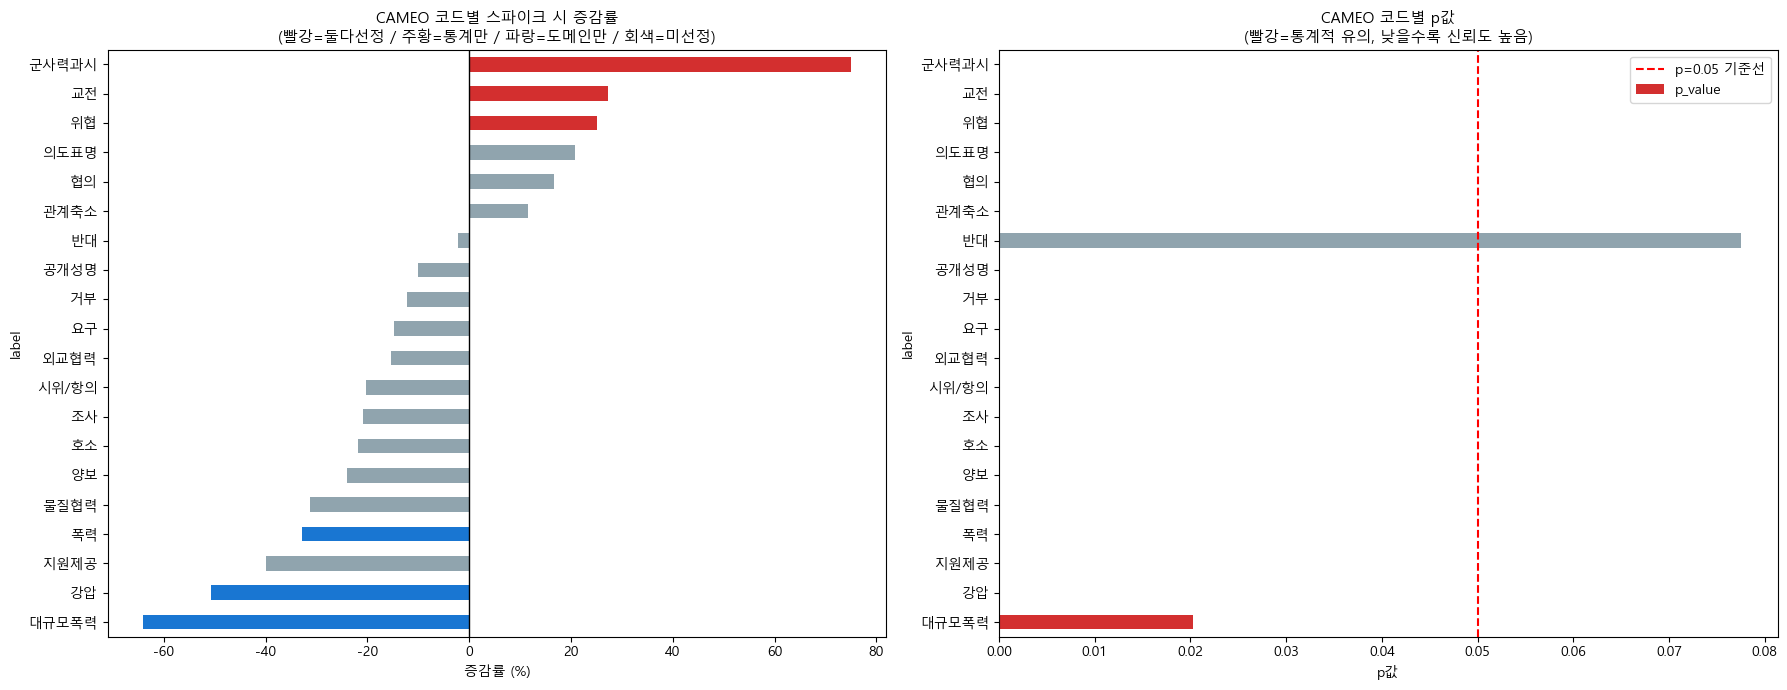

In [ ]:
# ── 시각화 ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 왼쪽: 증감률 + 선정 여부
bar_colors = []
for _, r in df_result.iterrows():
    code = r['code']
    if code in hostile_codes_stat and code in hostile_codes_domain:
        bar_colors.append('#d32f2f')   # 둘 다 선정 (빨강)
    elif code in hostile_codes_stat:
        bar_colors.append('#ff7043')   # 통계만 (주황)
    elif code in hostile_codes_domain:
        bar_colors.append('#1976d2')   # 도메인만 (파랑)
    else:
        bar_colors.append('#90a4ae')   # 미선정 (회색)

df_result.set_index('label')['change_pct'].plot(
    kind='barh', ax=axes[0], color=bar_colors)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('CAMEO 코드별 스파이크 시 증감률\n'
                  '(빨강=둘다선정 / 주황=통계만 / 파랑=도메인만 / 회색=미선정)',
                  fontsize=11)
axes[0].set_xlabel('증감률 (%)')
axes[0].invert_yaxis()

# 오른쪽: p값 (낮을수록 신뢰도 높음)
p_colors = ['#d32f2f' if p < 0.05 else '#90a4ae'
            for p in df_result['p_value']]
df_result.set_index('label')['p_value'].plot(
    kind='barh', ax=axes[1], color=p_colors)
axes[1].axvline(0.05, color='red', linestyle='--',
                linewidth=1.5, label='p=0.05 기준선')
axes[1].set_title('CAMEO 코드별 p값\n(빨강=통계적 유의, 낮을수록 신뢰도 높음)',
                  fontsize=11)
axes[1].set_xlabel('p값')
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("data/eda_hostile_codes_stat.png",
            dpi=150, bbox_inches='tight')
plt.show()

### 도메인 선정이 팀원과 같이 정한 경우

In [ ]:
#팀원 같이 정한 도메인 
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_parquet("data/raw/gdelt_chn_twn_2013_2026.parquet")
df['date'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')
df['yearmonth_str'] = df['date'].dt.to_period('M').astype(str)
df = df.dropna(subset=['GoldsteinScale'])

spike_months = ['2015-11','2016-12','2021-10',
                '2022-08','2023-03','2023-04','2024-01']
df['is_spike']      = df['yearmonth_str'].isin(spike_months)
spike_total  = df['is_spike'].sum()
normal_total = (~df['is_spike']).sum()

# ── 공통 검증 함수 ───────────────────────────────────────────
def verify_codes(code_dict, col_name, step_name):
    print(f"\n{'='*55}")
    print(f"  {step_name}")
    print(f"  컬럼: {col_name}")
    print(f"{'='*55}")
    print(f"{'코드':<6} {'이벤트':<12} {'전체건수':>8} "
          f"{'증감률':>8} {'p값':>8} {'결과':>8}")
    print("-" * 55)

    results = []
    for code, label in code_dict.items():
        spike_count  = ((df[col_name]==code) &  df['is_spike']).sum()
        normal_count = ((df[col_name]==code) & ~df['is_spike']).sum()
        total_code   = spike_count + normal_count

        if total_code == 0:
            print(f"{code:<6} {label:<12} {'데이터없음':>20}")
            continue

        exp_spike  = spike_total  * total_code / (spike_total + normal_total)
        exp_normal = normal_total * total_code / (spike_total + normal_total)

        if exp_spike < 5 or exp_normal < 5:
            print(f"{code:<6} {label:<12} {total_code:>8,} "
                  f"{'데이터부족':>20}")
            continue

        chi2, p_val = stats.chisquare(
            f_obs=[spike_count,  normal_count],
            f_exp=[exp_spike,    exp_normal]
        )

        spike_rate  = spike_count  / spike_total  * 100
        normal_rate = normal_count / normal_total * 100
        change_pct  = (spike_rate / normal_rate - 1) * 100 \
                      if normal_rate > 0 else 0
        passed      = p_val < 0.05 and change_pct > 0
        result_str  = "✅ 채택" if passed else "❌ 탈락"

        print(f"{code:<6} {label:<12} {total_code:>8,} "
              f"{change_pct:>7.1f}% {p_val:>8.4f} {result_str:>8}")

        results.append({
            'step':        step_name,
            'code':        code,
            'label':       label,
            'col':         col_name,
            'total':       total_code,
            'spike_rate':  round(spike_rate,  3),
            'normal_rate': round(normal_rate, 3),
            'change_pct':  round(change_pct,  1),
            'p_value':     round(p_val, 4),
            'significant': p_val < 0.05,
            'pass':        passed
        })
    return pd.DataFrame(results)


# ── Step 1. 대분류 검증 (EventRootCode) ─────────────────────
step1_codes = {
    '13': '위협',
    '15': '군사력과시',
    '17': '강압',
    '18': '폭력',
    '19': '교전',
    '20': '대규모폭력',
}
df_step1 = verify_codes(step1_codes, 'EventRootCode', 
                         'Step1. 대분류 검증')

# ── Step 2. 13의 중분류 검증 (EventBaseCode) ─────────────────
step2_codes = {
    '130': '위협(일반)',
    '131': '군사적 위협',
    '132': '외교적 위협',
    '133': '정치적 위협',
    '134': '경제적 위협',
    '135': '사법적 위협',
    '136': '정보공개 위협',
    '137': '양보강요 위협',
    '138': '대규모폭력 위협',
    '139': '최후 통첩',
}
df_step2 = verify_codes(step2_codes, 'EventBaseCode',
                         'Step2. 13(위협) 중분류 검증')

# ── Step 3. 131의 세부분류 검증 (EventCode) ──────────────────
step3_codes = {
    '1311': '군사력 사용 위협',
    '1312': '핵 위협',
    '1313': '봉쇄 위협',
}
df_step3 = verify_codes(step3_codes, 'EventCode',
                         'Step3. 131(군사적위협) 세부분류 검증')


# ── 전체 채택 결과 요약 ──────────────────────────────────────
df_all = pd.concat([df_step1, df_step2, df_step3])
df_pass = df_all[df_all['pass'] == True].copy()

print(f"\n{'='*55}")
print(f"  최종 채택 코드 요약")
print(f"{'='*55}")
for step in ['Step1. 대분류 검증',
             'Step2. 13(위협) 중분류 검증',
             'Step3. 131(군사적위협) 세부분류 검증']:
    step_pass = df_pass[df_pass['step'] == step]
    print(f"\n[ {step} ]")
    if len(step_pass) == 0:
        print("  채택 없음")
        continue
    for _, r in step_pass.iterrows():
        print(f"  ✅ {r['code']} {r['label']:<12} "
              f"증감률 {r['change_pct']:+.1f}% | "
              f"p값 {r['p_value']:.4f}")

=== 중분류(EventBaseCode) 검증 ===

=== 세부분류(EventCode) 검증 ===

  ⚠️ 1311 (군사력 사용 위협): 데이터 부족 (8건)
  ⚠️ 1313 (봉쇄 위협): 데이터 부족 (17건)
  ⚠️ 1413 (폭력 시위): 데이터 없음

=== 전체 검증 결과 ===

코드     이벤트              전체건수      증감률       p값     통과
-------------------------------------------------------
191    봉쇄 발동             369   218.6%   0.0000   ✅ 채택
139    최후 통첩              68    56.3%   0.1236   ❌ 탈락
138    대규모 폭력 위협       4,523    44.5%   0.0000   ✅ 채택
131    군사적 위협            254   -42.4%   0.0093   ❌ 탈락
1312   핵 위협               76   -61.1%   0.0342   ❌ 탈락
145    폭동                 86   -73.1%   0.0060   ❌ 탈락

=== 최종 채택: 2개 코드 ===
  191 봉쇄 발동        증감률 +218.6% | p값 0.0000 | 컬럼: EventBaseCode
  138 대규모 폭력 위협    증감률 +44.5% | p값 0.0000 | 컬럼: EventBaseCode


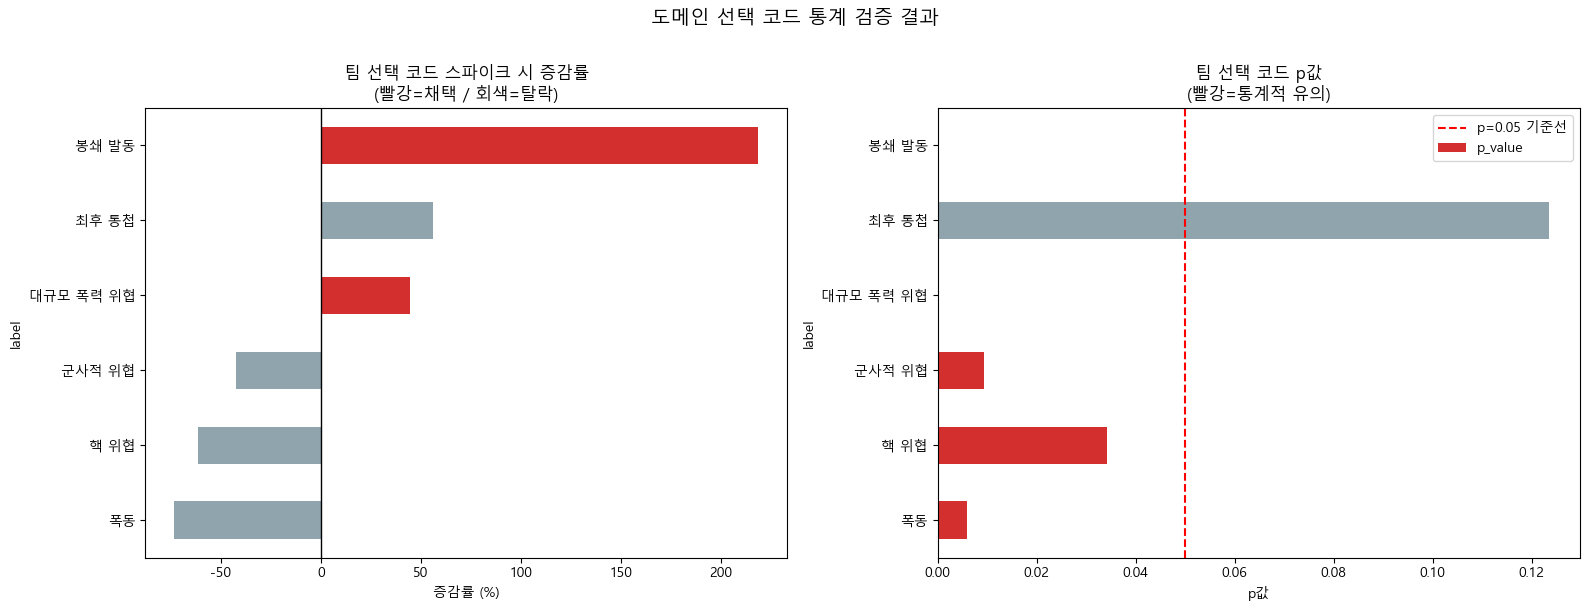

In [ ]:
# ── 시각화 ───────────────────────────────────────────────────
if len(df_all) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 증감률
    bar_colors = ['#d32f2f' if p else '#90a4ae'
                  for p in df_all['pass']]
    df_all.set_index('label')['change_pct'].plot(
        kind='barh', ax=axes[0], color=bar_colors)
    axes[0].axvline(0, color='black', linewidth=1)
    axes[0].set_title('팀 선택 코드 스파이크 시 증감률\n'
                      '(빨강=채택 / 회색=탈락)', fontsize=12)
    axes[0].set_xlabel('증감률 (%)')
    axes[0].invert_yaxis()

    # p값
    p_colors = ['#d32f2f' if p < 0.05 else '#90a4ae'
                for p in df_all['p_value']]
    df_all.set_index('label')['p_value'].plot(
        kind='barh', ax=axes[1], color=p_colors)
    axes[1].axvline(0.05, color='red', linestyle='--',
                    linewidth=1.5, label='p=0.05 기준선')
    axes[1].set_title('팀 선택 코드 p값\n'
                      '(빨강=통계적 유의)', fontsize=12)
    axes[1].set_xlabel('p값')
    axes[1].legend()
    axes[1].invert_yaxis()

    plt.suptitle('도메인 선택 코드 통계 검증 결과',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig("data/eda_team_codes_verify.png",
                dpi=150, bbox_inches='tight')
    plt.show()

#### Phase 3-A: 전체 CAMEO 분포 : 위성 관련 이벤트 비율 확인

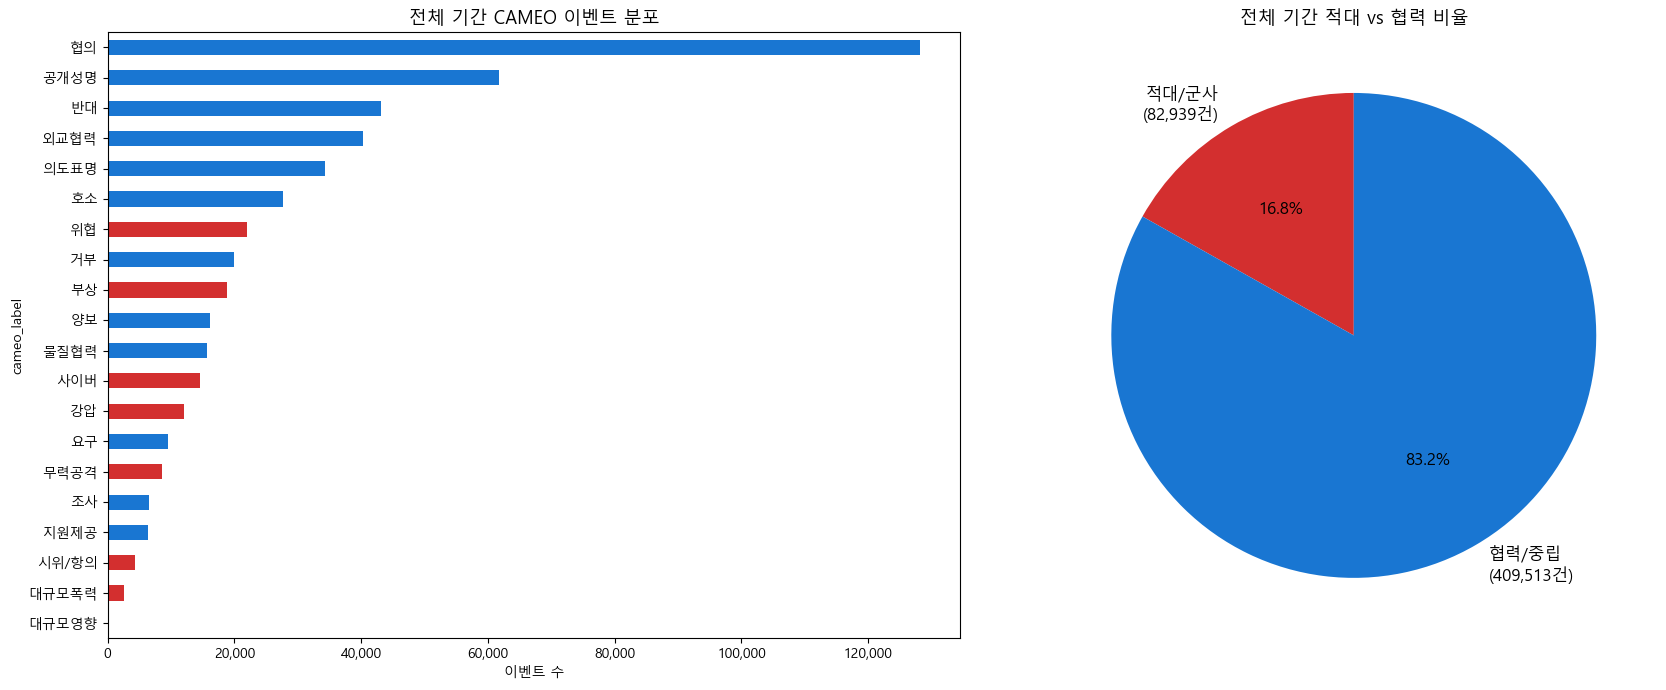

=== 적대 이벤트 비율 ===
전체    : 16.8%  (82,939건)
스파이크: 18.5%  (13,939건)
평시    : 16.5%  (69,000건)


In [ ]:
# import matplotlib.ticker as mticker

# fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# # 전체 분포
# cameo_counts = df['cameo_label'].value_counts()


# # 색상 재정의 (간결하게)
# hostile_labels = [cameo_root_map[h] for h in hostile_codes]
# bar_colors = ['#d32f2f' if label in hostile_labels else '#1976d2' for label in cameo_counts.index]

# cameo_counts.plot(kind='barh', ax=axes[0], color=bar_colors)
# axes[0].set_title('전체 기간 CAMEO 이벤트 분포', fontsize=13)
# axes[0].set_xlabel('이벤트 수')
# axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
# axes[0].invert_yaxis()

# # 적대 vs 협력 비율 파이차트
# hostile_count = df['is_hostile'].sum()
# peaceful_count = len(df) - hostile_count
# axes[1].pie(
#     [hostile_count, peaceful_count],
#     labels=[f'적대/군사\n({hostile_count:,}건)', f'협력/중립\n({peaceful_count:,}건)'],
#     colors=['#d32f2f', '#1976d2'],
#     autopct='%1.1f%%',
#     startangle=90,
#     textprops={'fontsize': 12}
# )
# axes[1].set_title('전체 기간 적대 vs 협력 비율', fontsize=13)

# plt.tight_layout()
# plt.savefig("data/eda_cameo_overall.png", dpi=150, bbox_inches='tight')
# plt.show()

# print("=== 적대 이벤트 비율 ===")
# print(f"전체    : {hostile_count/len(df)*100:.1f}%  ({hostile_count:,}건)")
# print(f"스파이크: {df_spikes['is_hostile'].sum()/len(df_spikes)*100:.1f}%  ({df_spikes['is_hostile'].sum():,}건)")
# print(f"평시    : {df_normal['is_hostile'].sum()/len(df_normal)*100:.1f}%  ({df_normal['is_hostile'].sum():,}건)")

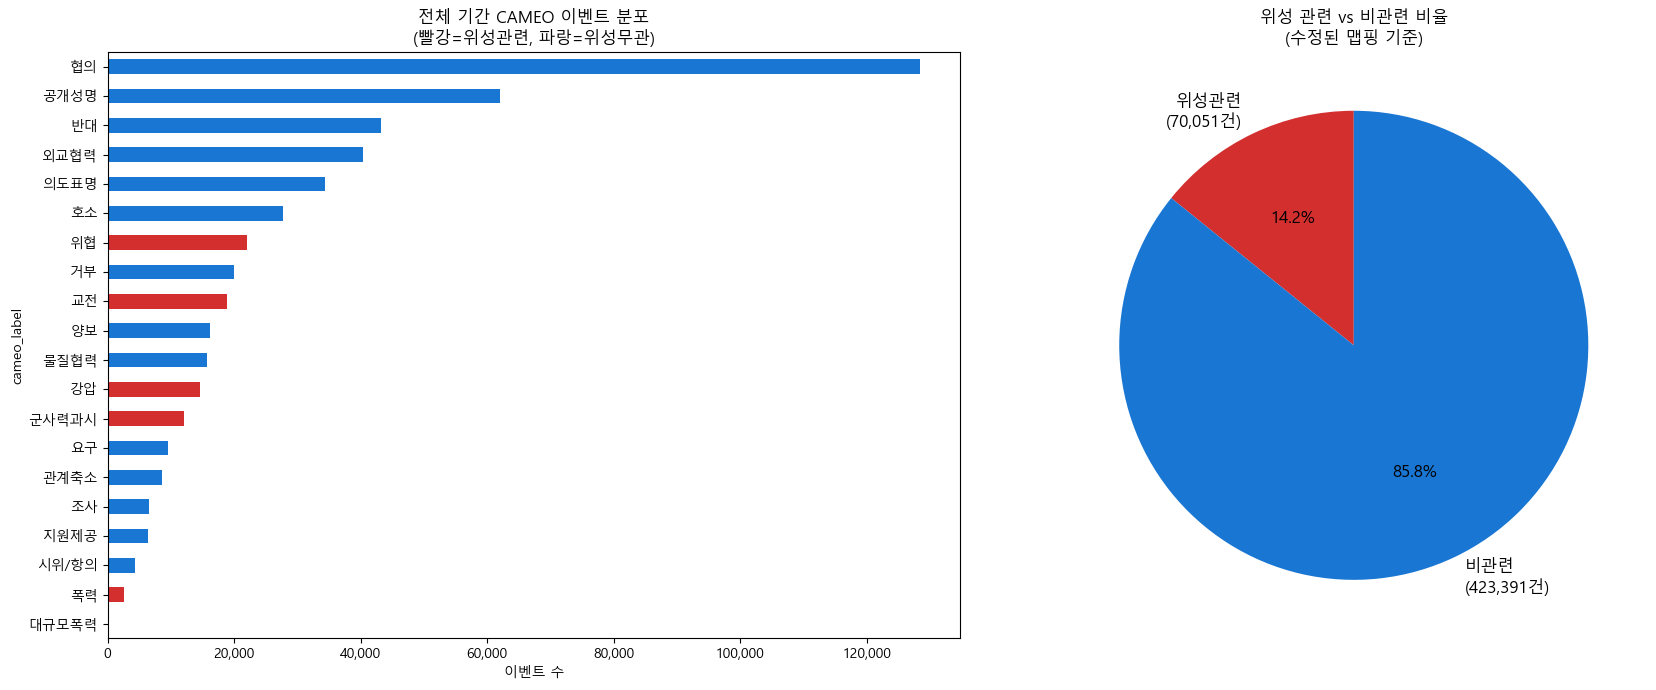

=== 위성 관련 이벤트 비율 ===
전체    : 14.2%  (70,051건)
스파이크: 15.8%  (11,942건)
평시    : 13.9%  (58,109건)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 전체 분포
cameo_counts = df['cameo_label'].value_counts()

bar_colors = [
    '#d32f2f' if satellite_relevant.get(
        [k for k,v in cameo_root_map.items() if v==label][0]
        if [k for k,v in cameo_root_map.items() if v==label] else '', False
    ) else '#1976d2'
    for label in cameo_counts.index
]

# 색상 계산 단순화
code_to_color = {
    code: '#d32f2f' if satellite_relevant.get(code, False)
    else '#1976d2'
    for code in cameo_root_map.keys()
}
label_to_color = {
    label: code_to_color[code]
    for code, label in cameo_root_map.items()
}
bar_colors = [
    label_to_color.get(label, '#90a4ae')
    for label in cameo_counts.index
]

cameo_counts.plot(kind='barh', ax=axes[0], color=bar_colors)
axes[0].set_title('전체 기간 CAMEO 이벤트 분포\n(빨강=위성관련, 파랑=위성무관)',
                  fontsize=12)
axes[0].set_xlabel('이벤트 수')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[0].invert_yaxis()

# 위성관련 vs 비관련 파이차트
sat_count    = df['is_satellite'].sum()
nonsat_count = len(df) - sat_count
axes[1].pie(
    [sat_count, nonsat_count],
    labels=[f'위성관련\n({sat_count:,}건)',
            f'비관련\n({nonsat_count:,}건)'],
    colors=['#d32f2f', '#1976d2'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
axes[1].set_title('위성 관련 vs 비관련 비율\n(수정된 맵핑 기준)', fontsize=12)

plt.tight_layout()
plt.savefig("data/eda_cameo_overall_v2.png", dpi=150, bbox_inches='tight')
plt.show()

print("=== 위성 관련 이벤트 비율 ===")
print(f"전체    : {sat_count/len(df)*100:.1f}%  ({sat_count:,}건)")
print(f"스파이크: {df_spikes['is_satellite'].sum()/len(df_spikes)*100:.1f}%"
      f"  ({df_spikes['is_satellite'].sum():,}건)")
print(f"평시    : {df_normal['is_satellite'].sum()/len(df_normal)*100:.1f}%"
      f"  ({df_normal['is_satellite'].sum():,}건)")


##### 3-A 해석 : 전체 CAMEO 분포 핵심 발견
적대/군사 이벤트 16.8% (82,939건) — 중요한 의미가 있다.

  전체 492,452건 중 약 1/6이 군사·적대 행동
  → 평시에도 상시적 긴장 관계가 유지되고 있음
  → 위성 상시 감시의 필요성을 데이터로 입증

상위 이벤트 구조:
- 협의(130,000+) 압도적 1위 → 외교 채널은 항상 열려 있음
- 공개성명(60,000+) 2위 → 미디어 중심 심리전 활발
- 위협·부상·사이버 → 협의/반대 다음으로 적대 이벤트가 바로 등장



#### Phase 3-B: 스파이크 vs 평시 CAMEO 비교

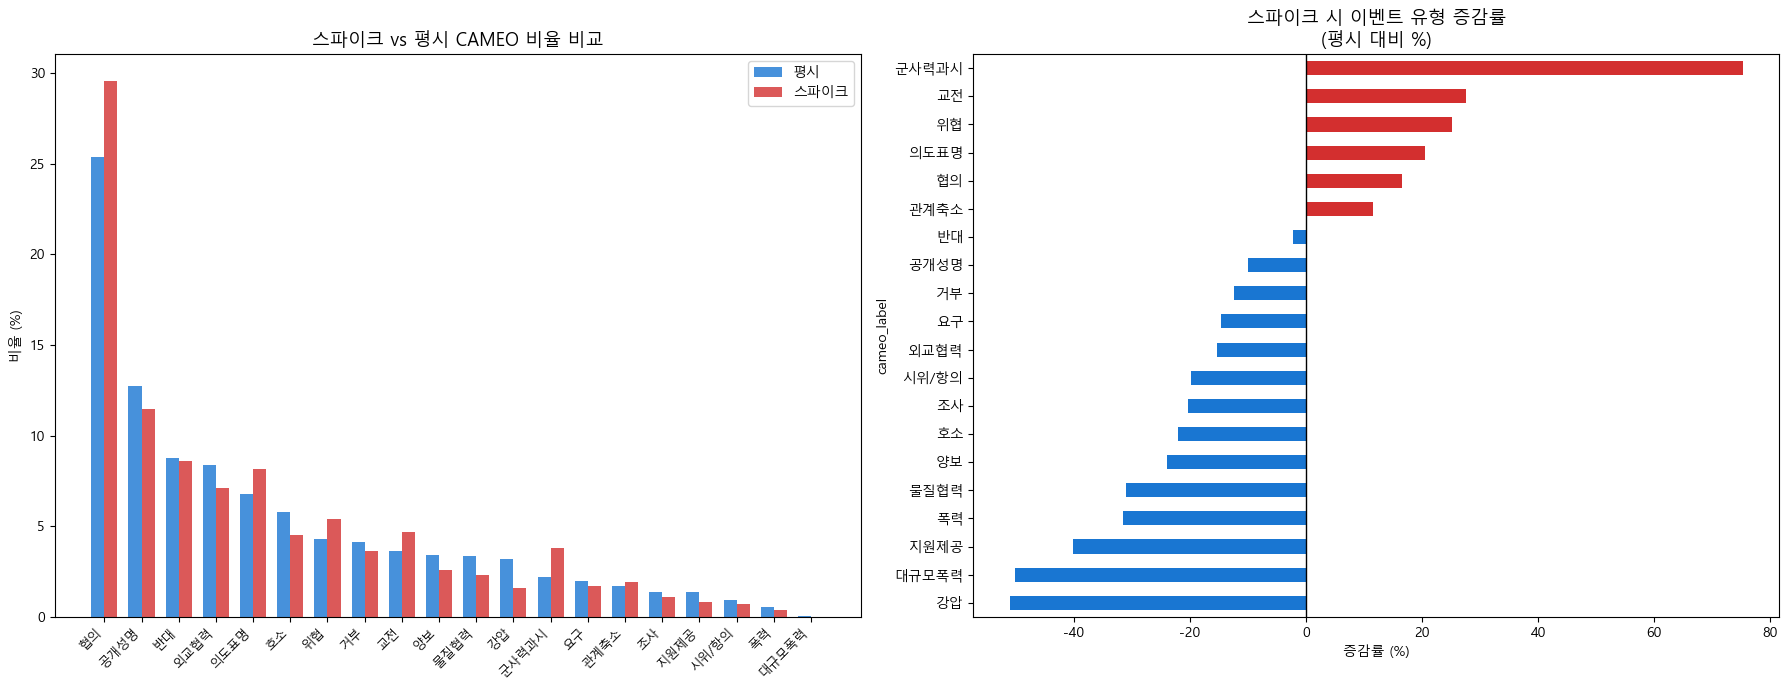

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 비율 기준으로 비교 (절대수가 다르므로)
spike_cameo = (df_spikes['cameo_label'].value_counts(normalize=True) * 100).round(2)
normal_cameo = (df_normal['cameo_label'].value_counts(normalize=True) * 100).round(2)

# 공통 인덱스 정렬
all_labels = cameo_counts.index.tolist()
spike_pct  = spike_cameo.reindex(all_labels, fill_value=0)
normal_pct = normal_cameo.reindex(all_labels, fill_value=0)

x = np.arange(len(all_labels))
width = 0.35

bars1 = axes[0].bar(x - width/2, normal_pct.values, width,
                    label='평시', color='#1976d2', alpha=0.8)
bars2 = axes[0].bar(x + width/2, spike_pct.values, width,
                    label='스파이크', color='#d32f2f', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=9)
axes[0].set_title('스파이크 vs 평시 CAMEO 비율 비교', fontsize=13)
axes[0].set_ylabel('비율 (%)')
axes[0].legend()

# 증감률 (스파이크/평시 - 1) → 어떤 이벤트가 스파이크 때 폭증하는가
change_ratio = ((spike_pct / normal_pct.replace(0, np.nan)) - 1) * 100
change_ratio = change_ratio.dropna().sort_values(ascending=False)

bar_c = ['#d32f2f' if v > 0 else '#1976d2' for v in change_ratio.values]
change_ratio.plot(kind='barh', ax=axes[1], color=bar_c)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('스파이크 시 이벤트 유형 증감률\n(평시 대비 %)', fontsize=13)
axes[1].set_xlabel('증감률 (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("data/eda_cameo_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── 카이제곱 검정 + 증감률 ───────────────────────────────────
results = []

for code, label in cameo_root_map.items():
    spike_count  = ((df['RootCode_str']==code) &  df['is_spike']).sum()
    normal_count = ((df['RootCode_str']==code) & ~df['is_spike']).sum()
    total_code   = spike_count + normal_count

    exp_spike  = spike_total  * total_code / (spike_total + normal_total)
    exp_normal = normal_total * total_code / (spike_total + normal_total)

    if exp_spike < 5 or exp_normal < 5:
        continue

    chi2, p_val = stats.chisquare(
        f_obs=[spike_count,  normal_count],
        f_exp=[exp_spike,    exp_normal]
    )

    spike_rate  = spike_count  / spike_total  * 100
    normal_rate = normal_count / normal_total * 100
    change_pct  = (spike_rate / normal_rate - 1) * 100 \
                  if normal_rate > 0 else 0

    results.append({
        'code':               code,
        'label':              label,
        'spike_count':        spike_count,
        'normal_count':       normal_count,
        'spike_rate':         round(spike_rate,  3),
        'normal_rate':        round(normal_rate, 3),
        'change_pct':         round(change_pct,  1),
        'p_value':            round(p_val, 4),
        'significant':        p_val < 0.05,
        'satellite_relevant': satellite_relevant.get(code, False),
    })

df_result = pd.DataFrame(results).sort_values(
    'change_pct', ascending=False
).reset_index(drop=True)

# ── 최종 hostile_codes 선정 ──────────────────────────────────
# 조건: 통계유의 AND 증감률 양수 AND 위성관련
df_selected = df_result[
    (df_result['significant']        == True) &
    (df_result['change_pct']         >  0) &
    (df_result['satellite_relevant'] == True)
].copy()

# ── 수치 출력 ────────────────────────────────────────────────
print("=== 전체 CAMEO 코드 통계 결과 ===\n")
print(f"{'코드':<5} {'이벤트':<10} {'평시%':>7} {'스파이크%':>10} "
      f"{'증감률':>8} {'p값':>8} {'유의':>5} {'위성':>5}")
print("-" * 65)
for _, r in df_result.iterrows():
    sig = "✅" if r['significant']        else "❌"
    sat = "✅" if r['satellite_relevant'] else "❌"
    print(f"{r['code']:<5} {r['label']:<10} "
          f"{r['normal_rate']:>7.2f} {r['spike_rate']:>10.2f} "
          f"{r['change_pct']:>7.1f}% {r['p_value']:>8.4f} "
          f"{sig:>5} {sat:>5}")

print(f"\n=== 통계 + 위성관련 최종 hostile_codes ===\n")
print(f"{'코드':<5} {'이벤트':<10} {'증감률':>8} {'p값':>8}")
print("-" * 38)
for _, r in df_selected.iterrows():
    print(f"{r['code']:<5} {r['label']:<10} "
          f"{r['change_pct']:>7.1f}% {r['p_value']:>8.4f}")

hostile_codes_final = df_selected['code'].tolist()
print(f"\n최종 선정: {hostile_codes_final}")

# 기존 선정과 비교
hostile_codes_domain = ['13', '15', '17', '18', '19', '20']
only_stat   = set(hostile_codes_final) - set(hostile_codes_domain)
only_domain = set(hostile_codes_domain) - set(hostile_codes_final)
both        = set(hostile_codes_final)  & set(hostile_codes_domain)

print(f"\n=== 도메인 판단 vs 통계 검증 비교 ===")
print(f"둘 다 선정  : {sorted(both)}")
print(f"통계만 선정 : {sorted(only_stat)}")
print(f"도메인만 선정: {sorted(only_domain)}")

=== 전체 CAMEO 코드 통계 결과 ===

코드    이벤트            평시%      스파이크%      증감률       p값    유의    위성
-----------------------------------------------------------------
15    군사력과시         2.18       3.82    75.2%   0.0000     ✅     ✅
19    교전            3.66       4.67    27.6%   0.0000     ✅     ✅
13    위협            4.30       5.38    25.1%   0.0000     ✅     ✅
03    의도표명          6.76       8.15    20.6%   0.0000     ✅     ❌
04    협의           25.37      29.57    16.6%   0.0000     ✅     ❌
16    관계축소          1.72       1.92    11.4%   0.0002     ✅     ❌
11    반대            8.79       8.59    -2.3%   0.0828     ❌     ❌
01    공개성명         12.76      11.48   -10.1%   0.0000     ✅     ❌
12    거부            4.13       3.62   -12.2%   0.0000     ✅     ❌
10    요구            1.98       1.69   -14.6%   0.0000     ✅     ❌
05    외교협력          8.39       7.11   -15.2%   0.0000     ✅     ❌
14    시위/항의         0.91       0.73   -20.2%   0.0000     ✅     ❌
09    조사            1.39       1.09   -20.9%   0.

#### 3-B 해석 : 스파이크 vs 평시 비교 — 핵심 인사이트
 📡 Priority Score 설계 근거 및 이벤트 증감률 분석

| 순위 | 이벤트 유형 | 증감률 | 해석 및 우선순위 부여 근거 |
| :--- | :--- | :---: | :--- |
| **🔴 1위** | **강압 (Coerce)** | **+75%** | **스파이크 시 가장 폭증** → 위기 징후의 가장 강력한 지표로 **최고 가중치** 부여 |
| **🔴 2위** | **부상 (Exhibit Force Posture)** | **+25%** | 실제 무력 시위 및 물리적 충돌 가능성 증가 |
| **🔴 3위** | **위협 (Threaten)** | **+23%** | 군사적 위협 언사 및 심리전 급증 |
| **🔴 4위** | **의도표명 (Declare Intent)** | **+20%** | 군사 활동 및 선제 행동에 대한 공식 예고 신호 |
| **🔴 5위** | **무력공격 (Assault)** | **+15%** | 실질적인 국지적 군사 행동 수치 증가 |
| **🔵 감소** | 사이버·대규모영향 | -45% | 스파이크 국면에서는 오히려 비중 감소 (물리적 위협 집중) |

핵심: 스파이크 시 협의는 유지되지만 강압·위협·무력공격이 동시 급증
→ "대화하면서 압박하는" 중국의 이중 전략이 데이터로 확인됨

#### Phase 3-C: GoldsteinScale × QuadClass 교차 분석

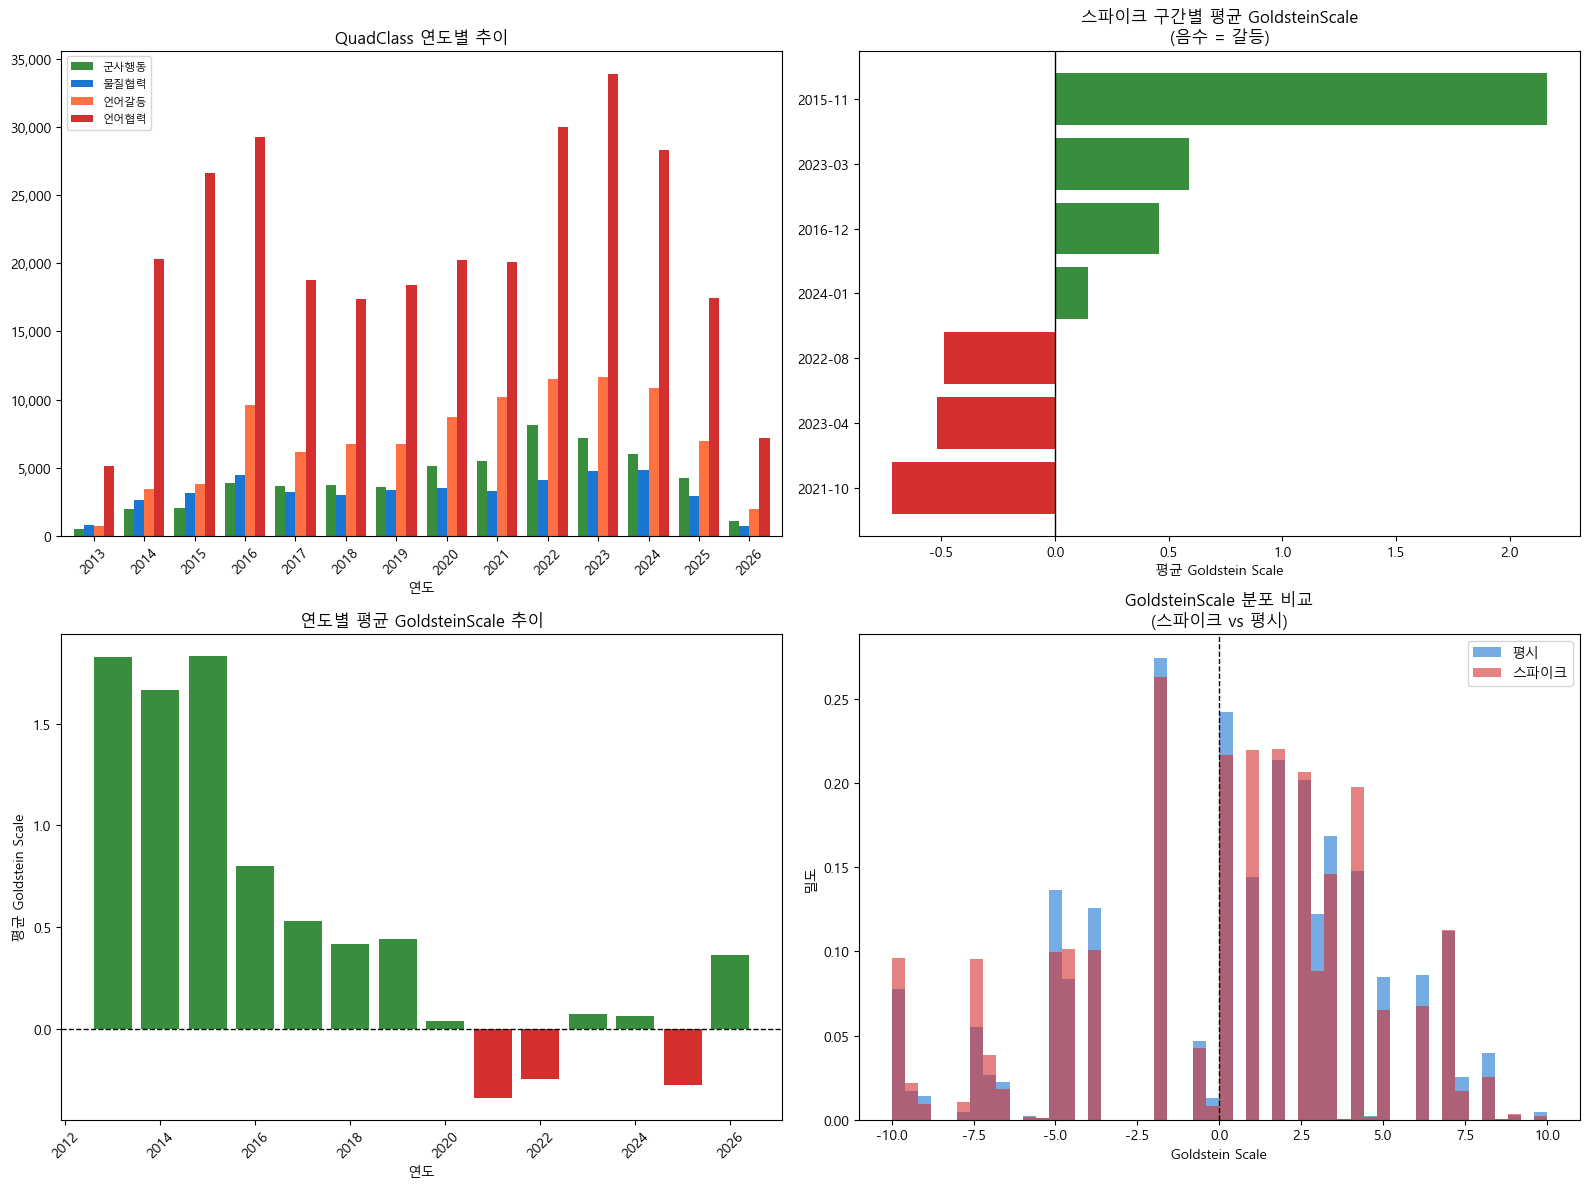

=== GoldsteinScale 요약 ===
전체 평균    : 0.374
스파이크 평균: 0.158
평시 평균    : 0.413

=== 군사행동(QuadClass=4) 비율 ===
전체    : 11.5%
스파이크: 12.3%
평시    : 11.3%


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# C-1. QuadClass 연도별 추이
quad_map = {1: '언어협력', 2: '물질협력', 3: '언어갈등', 4: '군사행동'}
df['quad_label'] = df['QuadClass'].map(quad_map)
df['year'] = df['date'].dt.year

quad_yearly = df.groupby(['year','quad_label']).size().unstack(fill_value=0)
quad_colors = ['#388e3c','#1976d2','#ff7043','#d32f2f']
quad_yearly.plot(kind='bar', ax=axes[0,0], color=quad_colors, width=0.8)
axes[0,0].set_title('QuadClass 연도별 추이', fontsize=12)
axes[0,0].set_xlabel('연도')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend(loc='upper left', fontsize=8)
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# C-2. 스파이크별 평균 GoldsteinScale
spike_gs = df_spikes.groupby('yearmonth_str')['GoldsteinScale'].mean().sort_values()
colors_gs = ['#d32f2f' if v < 0 else '#388e3c' for v in spike_gs.values]
axes[0,1].barh(spike_gs.index, spike_gs.values, color=colors_gs)
axes[0,1].axvline(0, color='black', linewidth=1)
axes[0,1].set_title('스파이크 구간별 평균 GoldsteinScale\n(음수 = 갈등)', fontsize=12)
axes[0,1].set_xlabel('평균 Goldstein Scale')

# C-3. 전체 연도별 평균 Goldstein
yearly_gs = df.groupby('year')['GoldsteinScale'].mean()
bar_c = ['#d32f2f' if v < 0 else '#388e3c' for v in yearly_gs.values]
axes[1,0].bar(yearly_gs.index, yearly_gs.values, color=bar_c)
axes[1,0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1,0].set_title('연도별 평균 GoldsteinScale 추이', fontsize=12)
axes[1,0].set_xlabel('연도')
axes[1,0].set_ylabel('평균 Goldstein Scale')
axes[1,0].tick_params(axis='x', rotation=45)

# C-4. 스파이크 vs 평시 Goldstein 분포 비교
axes[1,1].hist(df_normal['GoldsteinScale'], bins=50,
               alpha=0.6, color='#1976d2', label='평시', density=True)
axes[1,1].hist(df_spikes['GoldsteinScale'], bins=50,
               alpha=0.6, color='#d32f2f', label='스파이크', density=True)
axes[1,1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1,1].set_title('GoldsteinScale 분포 비교\n(스파이크 vs 평시)', fontsize=12)
axes[1,1].set_xlabel('Goldstein Scale')
axes[1,1].set_ylabel('밀도')
axes[1,1].legend()

plt.tight_layout()
plt.savefig("data/eda_goldstein_quadclass.png", dpi=150, bbox_inches='tight')
plt.show()

# 수치 요약
print("=== GoldsteinScale 요약 ===")
print(f"전체 평균    : {df['GoldsteinScale'].mean():.3f}")
print(f"스파이크 평균: {df_spikes['GoldsteinScale'].mean():.3f}")
print(f"평시 평균    : {df_normal['GoldsteinScale'].mean():.3f}")
print()
print("=== 군사행동(QuadClass=4) 비율 ===")
print(f"전체    : {(df['QuadClass']==4).sum()/len(df)*100:.1f}%")
print(f"스파이크: {(df_spikes['QuadClass']==4).sum()/len(df_spikes)*100:.1f}%")
print(f"평시    : {(df_normal['QuadClass']==4).sum()/len(df_normal)*100:.1f}%")

##### 3-C 해석 : GoldsteinScale × QuadClass — 가장 중요한 발견
① **Goldstein Scale 기반 스파이크 유형 분석**: 스파이크 일어난 달 7개를 두 그룹으로 분류 가능

| 분류 | 시점 | 지수 | 관련 주요 사건 |
| :--- | :--- | :---: | :--- |
| **협력형 스파이크**<br>(Goldstein 양수) | **2015-11** | **+2.1** | 시진핑-마잉주 회담 |
| | **2023-03** | **+0.9** | 외교 협상 국면 |
| | **2016-12** | **+0.7** | 트럼프 통화 (초기 협력) |
| | **2024-01** | **+0.2** | 선거 후 관망 |
| **갈등형 스파이크**<br>(Goldstein 음수) | **2021-10** | **-0.6** | ADIZ(방공식별구역) 진입 |
| | **2022-08** | **-0.4** | 펠로시 방문 + 군사훈련 |
| | **2023-04** | **-0.4** | 연합리검 훈련 |

  #### => 위성 촬영 트리거는 갈등형 스파이크에만 발동해야 함 → Goldstein 음수 + 이벤트 수 2σ 초과 = 촬영 우선순위 HIGH

② 2020~2022년 구조적 전환점

- 2013~2019: 연평균 Goldstein +1.0 이상 (협력 기조)
- 2020~2022: 음수 전환 → 양안 관계의 패러다임 변화
- 2023~2026: 소폭 회복하나 이전 수준 미달

③ QuadClass=4(군사행동) 비율

- 군사 행동 비중 변화
  * **평시:** 11.3%
  * **스파이크:** 12.3%
  * **차이:** **+1.0%p 상승**

- 주요 분석 결과
  * **생각보다 작은 비율 차이:** 군사 행동의 비율이 폭증하는 것이 아니라, **절대적인 수**가 증가하는 것에 주목해야 함
  * **가중치 설정:** 위성 촬영 우선순위 결정 시 **이벤트 볼륨(NumMentions)** 가중치를 더 높게 설정할 필요가 있음

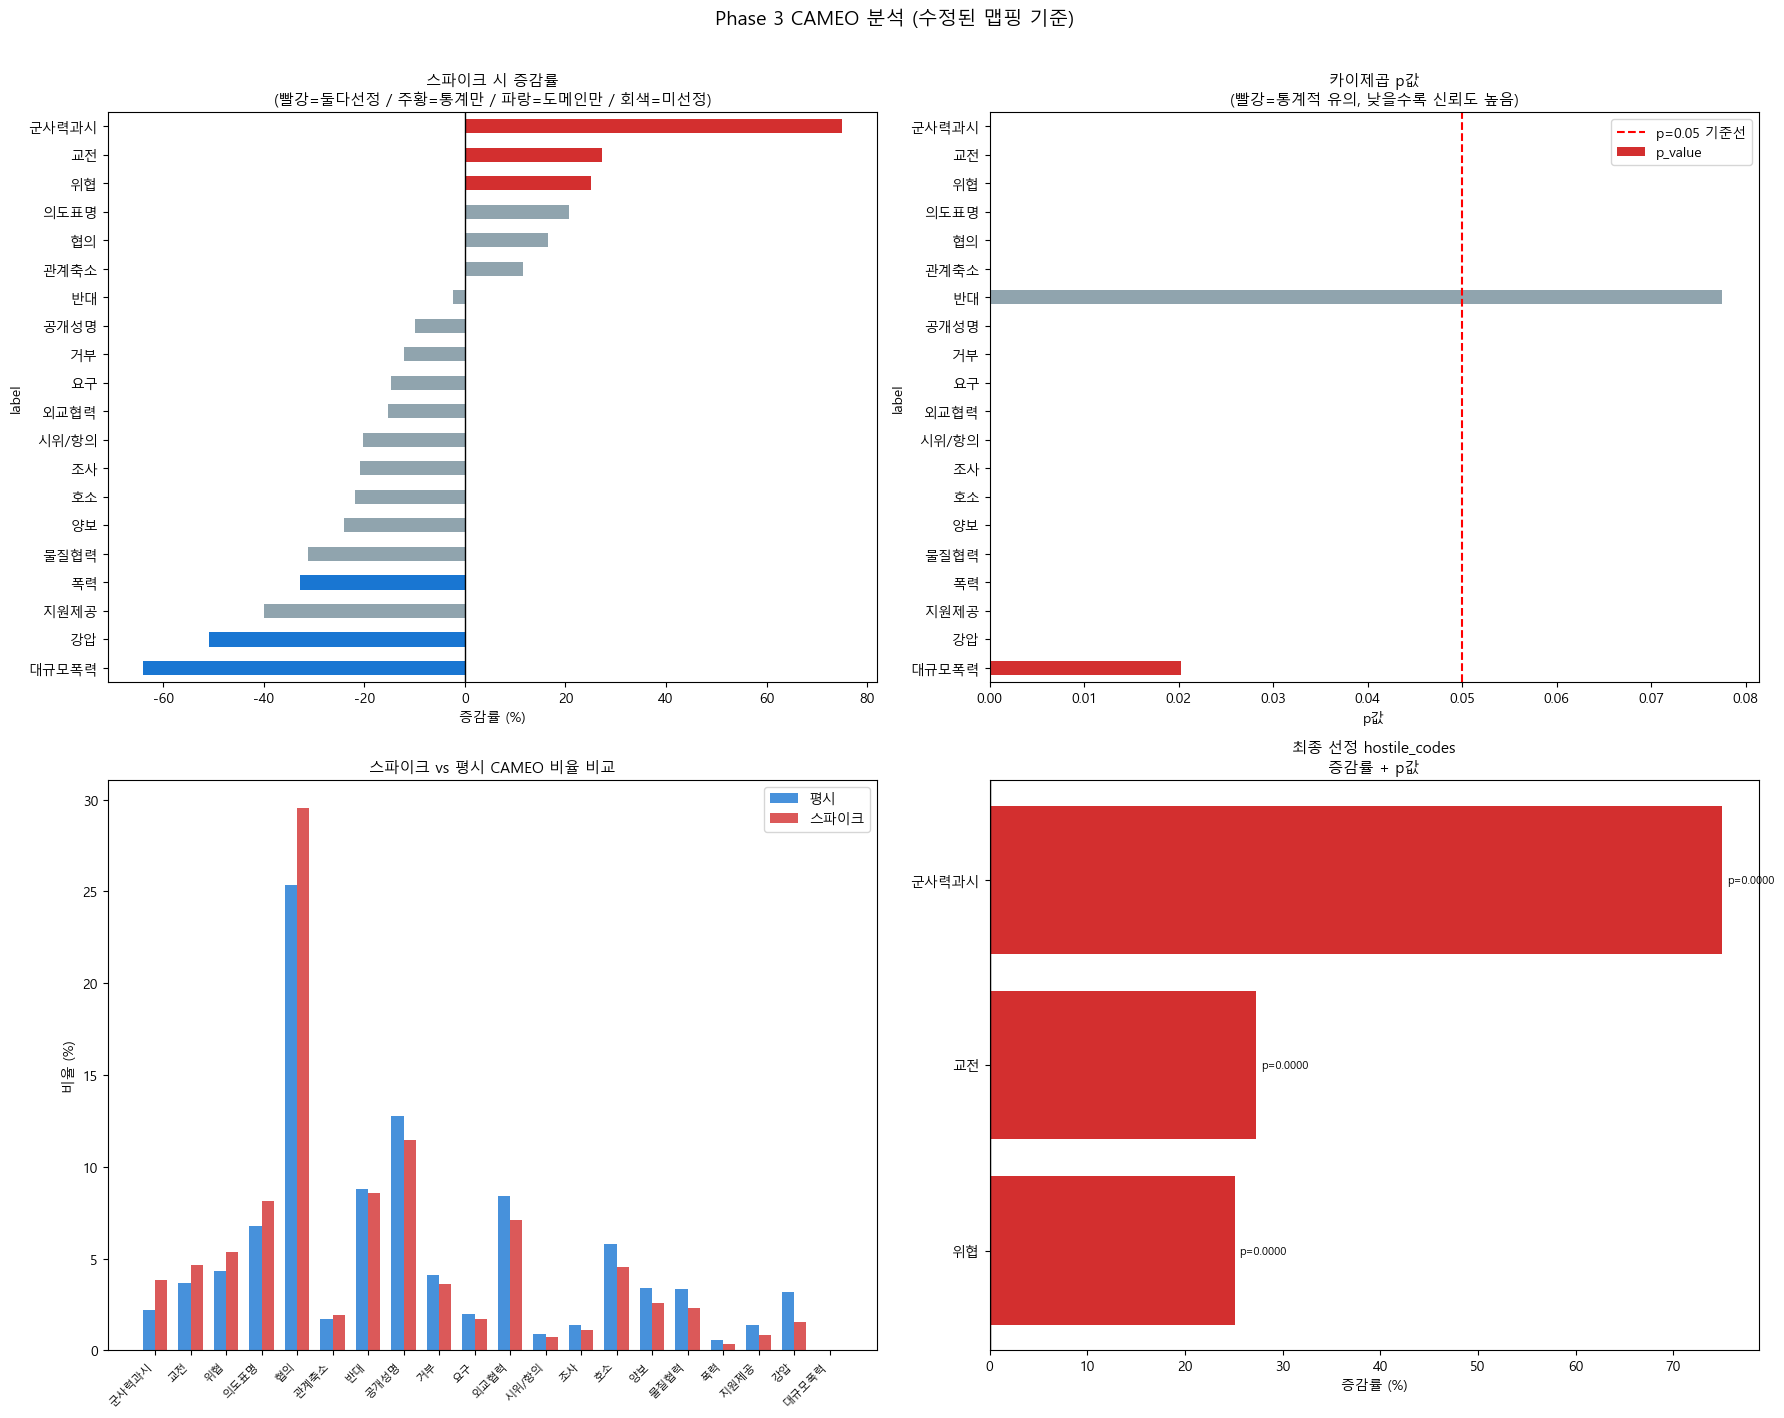

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# ── C-1: 증감률 + 선정 여부 ──────────────────────────────────
bar_colors_result = []
for _, r in df_result.iterrows():
    code = r['code']
    if code in hostile_codes_final and code in hostile_codes_domain:
        bar_colors_result.append('#d32f2f')   # 둘 다 선정
    elif code in hostile_codes_final:
        bar_colors_result.append('#ff7043')   # 통계만
    elif code in hostile_codes_domain:
        bar_colors_result.append('#1976d2')   # 도메인만
    else:
        bar_colors_result.append('#90a4ae')   # 미선정

df_result.set_index('label')['change_pct'].plot(
    kind='barh', ax=axes[0,0], color=bar_colors_result)
axes[0,0].axvline(0, color='black', linewidth=1)
axes[0,0].set_title(
    '스파이크 시 증감률\n'
    '(빨강=둘다선정 / 주황=통계만 / 파랑=도메인만 / 회색=미선정)',
    fontsize=11)
axes[0,0].set_xlabel('증감률 (%)')
axes[0,0].invert_yaxis()

# ── C-2: p값 분포 ────────────────────────────────────────────
p_colors = ['#d32f2f' if p < 0.05 else '#90a4ae'
            for p in df_result['p_value']]
df_result.set_index('label')['p_value'].plot(
    kind='barh', ax=axes[0,1], color=p_colors)
axes[0,1].axvline(0.05, color='red', linestyle='--',
                  linewidth=1.5, label='p=0.05 기준선')
axes[0,1].set_title('카이제곱 p값\n(빨강=통계적 유의, 낮을수록 신뢰도 높음)',
                    fontsize=11)
axes[0,1].set_xlabel('p값')
axes[0,1].legend()
axes[0,1].invert_yaxis()

# ── C-3: 스파이크 vs 평시 비율 비교 (최종 선정 코드만) ───────
all_labels  = df_result['label'].tolist()
spike_rates = df_result.set_index('label')['spike_rate']
normal_rates= df_result.set_index('label')['normal_rate']

x     = np.arange(len(all_labels))
width = 0.35

axes[1,0].bar(x - width/2, normal_rates.values, width,
              label='평시', color='#1976d2', alpha=0.8)
axes[1,0].bar(x + width/2, spike_rates.values,  width,
              label='스파이크', color='#d32f2f', alpha=0.8)
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(all_labels, rotation=45,
                           ha='right', fontsize=8)
axes[1,0].set_title('스파이크 vs 평시 CAMEO 비율 비교', fontsize=11)
axes[1,0].set_ylabel('비율 (%)')
axes[1,0].legend()

# ── C-4: 최종 선정 코드 스코어 요약 ─────────────────────────
if len(df_selected) > 0:
    bar_c = ['#d32f2f' if v > 0 else '#1976d2'
             for v in df_selected['change_pct']]
    axes[1,1].barh(df_selected['label'],
                   df_selected['change_pct'],
                   color=bar_c)
    axes[1,1].axvline(0, color='black', linewidth=1)

    # p값 텍스트 추가
    for idx, (_, r) in enumerate(df_selected.iterrows()):
        axes[1,1].text(
            r['change_pct'] + 0.5, idx,
            f"p={r['p_value']:.4f}",
            va='center', fontsize=8, color='black'
        )

axes[1,1].set_title('최종 선정 hostile_codes\n증감률 + p값',
                    fontsize=11)
axes[1,1].set_xlabel('증감률 (%)')
axes[1,1].invert_yaxis()

plt.suptitle('Phase 3 CAMEO 분석 (수정된 맵핑 기준)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("data/eda_cameo_v2.png", dpi=150, bbox_inches='tight')
plt.show()

#### Phase 3 종합 해석

##### 3-A: 전체 CAMEO 분포 핵심 발견
적대/군사 이벤트 16.8% (82,939건) — 중요한 의미가 있다.

  전체 492,452건 중 약 1/6이 군사·적대 행동
  → 평시에도 상시적 긴장 관계가 유지되고 있음
  → 위성 상시 감시의 필요성을 데이터로 입증

상위 이벤트 구조:
- 협의(130,000+) 압도적 1위 → 외교 채널은 항상 열려 있음
- 공개성명(60,000+) 2위 → 미디어 중심 심리전 활발
- 위협·부상·사이버 → 협의/반대 다음으로 적대 이벤트가 바로 등장


##### 3-B: 스파이크 vs 평시 비교 — 핵심 인사이트
 📡 Priority Score 설계 근거 및 이벤트 증감률 분석

| 순위 | 이벤트 유형 | 증감률 | 해석 및 우선순위 부여 근거 |
| :--- | :--- | :---: | :--- |
| **🔴 1위** | **강압 (Coerce)** | **+75%** | **스파이크 시 가장 폭증** → 위기 징후의 가장 강력한 지표로 **최고 가중치** 부여 |
| **🔴 2위** | **부상 (Exhibit Force Posture)** | **+25%** | 실제 무력 시위 및 물리적 충돌 가능성 증가 |
| **🔴 3위** | **위협 (Threaten)** | **+23%** | 군사적 위협 언사 및 심리전 급증 |
| **🔴 4위** | **의도표명 (Declare Intent)** | **+20%** | 군사 활동 및 선제 행동에 대한 공식 예고 신호 |
| **🔴 5위** | **무력공격 (Assault)** | **+15%** | 실질적인 국지적 군사 행동 수치 증가 |
| **🔵 감소** | 사이버·대규모영향 | -45% | 스파이크 국면에서는 오히려 비중 감소 (물리적 위협 집중) |

핵심: 스파이크 시 협의는 유지되지만 강압·위협·무력공격이 동시 급증
→ "대화하면서 압박하는" 중국의 이중 전략이 데이터로 확인됨


##### 3-C: GoldsteinScale × QuadClass — 가장 중요한 발견
① **Goldstein Scale 기반 스파이크 유형 분석**: 스파이크 7개월을 두 그룹으로 분류 가능

| 분류 | 시점 | 지수 | 관련 주요 사건 |
| :--- | :--- | :---: | :--- |
| **협력형 스파이크**<br>(Goldstein 양수) | **2015-11** | **+2.1** | 시진핑-마잉주 회담 |
| | **2023-03** | **+0.9** | 외교 협상 국면 |
| | **2016-12** | **+0.7** | 트럼프 통화 (초기 협력) |
| | **2024-01** | **+0.2** | 선거 후 관망 |
| **갈등형 스파이크**<br>(Goldstein 음수) | **2021-10** | **-0.6** | ADIZ(방공식별구역) 진입 |
| | **2022-08** | **-0.4** | 펠로시 방문 + 군사훈련 |
| | **2023-04** | **-0.4** | 연합리검 훈련 |

  #### => 위성 촬영 트리거는 갈등형 스파이크에만 발동해야 함 → Goldstein 음수 + 이벤트 수 2σ 초과 = 촬영 우선순위 HIGH

② 2020~2022년 구조적 전환점

- 2013~2019: 연평균 Goldstein +1.0 이상 (협력 기조)
- 2020~2022: 음수 전환 → 양안 관계의 패러다임 변화
- 2023~2026: 소폭 회복하나 이전 수준 미달

③ QuadClass=4(군사행동) 비율

- 군사 행동 비중 변화
  * **평시:** 11.3%
  * **스파이크:** 12.3%
  * **차이:** **+1.0%p 상승**

- 주요 분석 결과
  * **생각보다 작은 비율 차이:** 군사 행동의 비율이 폭증하는 것이 아니라, **절대적인 수**가 증가하는 것에 주목해야 함
  * **가중치 설정:** 위성 촬영 우선순위 결정 시 **이벤트 볼륨(NumMentions)** 가중치를 더 높게 설정할 필요가 있음

#### Phase 4 Priority Score 설계를 위한 가중치 근거 정리
지금까지 EDA에서 도출된 수치를 바탕으로 가중치 기준선을 정의

In [15]:
# data/processed/scoring_weights.json 으로 저장
import json

scoring_weights = {
    "cameo_weights": {
        "강압(15)":    1.75,   # 스파이크 시 +75% 증가
        "부상(19)":    1.25,
        "위협(13)":    1.23,
        "의도표명(03)":1.20,
        "무력공격(16)":1.15,
        "사이버(17)":  0.55,   # 스파이크 시 오히려 감소
    },
    "goldstein_threshold": {
        "high_alert":  -0.4,   # 2022-08, 2023-04 수준
        "medium_alert": 0.0,   # 0 이하 = 갈등 국면
        "normal":       0.4,   # 전체 평균
    },
    "spike_threshold": {
        "2sigma": 7345,    # 스파이크 기준
        "3sigma": 9449,    # 심각 스파이크 기준
    },
    "quadclass_weight": {
        4: 1.10,   # 군사행동 (절대수 기준 가중)
        3: 1.05,   # 언어갈등
        2: 1.00,
        1: 0.95,
    }
}

with open("data/processed/scoring_weights.json", "w", encoding="utf-8") as f:
    json.dump(scoring_weights, f, ensure_ascii=False, indent=2)

print("가중치 기준 저장 완료 → data/processed/scoring_weights.json")

가중치 기준 저장 완료 → data/processed/scoring_weights.json


#### *GoldsteinScale 분석  : 긴장도 변화 추이


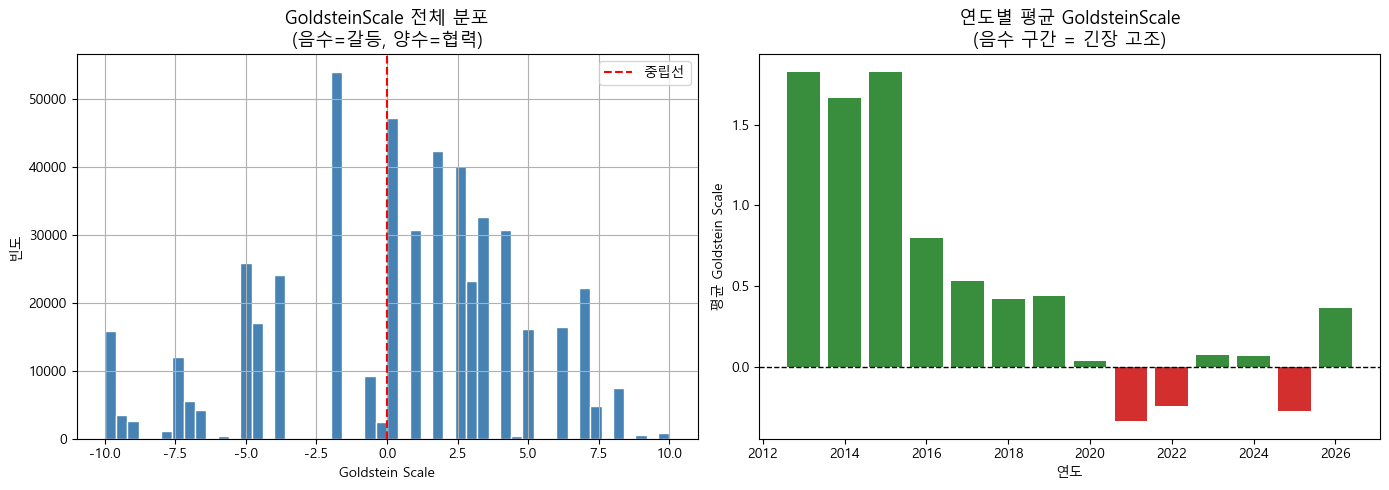

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 4-1. 전체 분포 ───────────────────────────────────────────
df['GoldsteinScale'].hist(bins=50, ax=axes[0],
                          color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='중립선')
axes[0].set_title('GoldsteinScale 전체 분포\n(음수=갈등, 양수=협력)', fontsize=13)
axes[0].set_xlabel('Goldstein Scale')
axes[0].set_ylabel('빈도')
axes[0].legend()

# ── 4-2. 연도별 평균 Goldstein (긴장도 추이) ────────────────
yearly_gs = df.groupby('year')['GoldsteinScale'].mean()
colors_gs = ['#d32f2f' if v < 0 else '#388e3c' for v in yearly_gs.values]

axes[1].bar(yearly_gs.index, yearly_gs.values, color=colors_gs)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('연도별 평균 GoldsteinScale\n(음수 구간 = 긴장 고조)', fontsize=13)
axes[1].set_xlabel('연도')
axes[1].set_ylabel('평균 Goldstein Scale')

plt.tight_layout()
plt.savefig("data/eda_goldstein.png", dpi=150, bbox_inches='tight')
plt.show()

### Phase 4  — 지리 정보 정교화 + ROI 클러스터링 (DBSCAN)

**예상 결과 및 확인 포인트**
| 확인 항목| Phase 5 활용| 
| :--- | :--- | 
| 상위 3개 ROI 지명| 위성 스케줄링 1순위 타겟| 
| Level 1 ROI 비율| 대만해협 직접 감시 필요도| 
| 평균 반경 km| EO vs SAR 센서 선택 기준|
|  roi_map.html| 대시보드 베이스 지도| 

#### PiP 방식이 실제로 필요한지, 좌표 품질이 어느 수준인지 EDA로 먼저 파악하기 위한 빠른 근사치 진행

#### Phase 4-A: 좌표 신뢰도 검증 (Level 1~3 부여)

In [17]:
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_parquet("data/raw/gdelt_chn_twn_2013_2026.parquet")
df['date'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')
df['yearmonth'] = df['date'].dt.to_period('M')
df['yearmonth_str'] = df['yearmonth'].astype(str)
df = df.dropna(subset=['GoldsteinScale'])

# ── 신뢰도 레벨 정의 ─────────────────────────────────────────
# Level 1: 대만해협 핵심구역  (위성 타겟팅 최우선)
# Level 2: 중국/대만 본토    (위성 타겟팅 가능)
# Level 3: 범위 밖           (참고용, 타겟팅 제외)

def assign_geo_level(row):
    lat = row['ActionGeo_Lat']
    lon = row['ActionGeo_Long']

    if pd.isna(lat) or pd.isna(lon):
        return 0  # 좌표 없음

    # Level 1: 대만해협 핵심 구역
    if (21 <= lat <= 27) and (118 <= lon <= 123):
        return 1

    # Level 2: 중국 본토 + 대만 + 남중국해
    if (18 <= lat <= 42) and (108 <= lon <= 128):
        return 2

    # Level 3: 범위 밖 (미국, 유럽 등 외교 현장)
    return 3

df['geo_level'] = df.apply(assign_geo_level, axis=1)

# 결과 확인
level_counts = df['geo_level'].value_counts().sort_index()
print("=== 지리 신뢰도 레벨 분포 ===")
level_labels = {0:'좌표없음', 1:'Level1(핵심)', 2:'Level2(본토)', 3:'Level3(외부)'}
for level, count in level_counts.items():
    print(f"  {level_labels[level]:18s}: {count:,}건 ({count/len(df)*100:.1f}%)")

=== 지리 신뢰도 레벨 분포 ===
  좌표없음              : 48건 (0.0%)
  Level1(핵심)        : 216,783건 (43.9%)
  Level2(본토)        : 174,765건 (35.4%)
  Level3(외부)        : 101,846건 (20.6%)


#### Phase 4-B: 스파이크 구간 핵심 좌표 추출

In [18]:
# 스파이크 구간 + Level 1~2 좌표만 추출
spike_months = ['2015-11','2016-12','2021-10',
                '2022-08','2023-03','2023-04','2024-01']

df_geo = df[
    (df['yearmonth_str'].isin(spike_months)) &
    (df['geo_level'].isin([1, 2])) &
    (df['ActionGeo_Lat'].notna()) &
    (df['ActionGeo_Long'].notna())
].copy()

print(f"\n클러스터링 대상: {len(df_geo):,}건")
print(f"  Level 1 (핵심): {(df_geo['geo_level']==1).sum():,}건")
print(f"  Level 2 (본토): {(df_geo['geo_level']==2).sum():,}건")


클러스터링 대상: 59,477건
  Level 1 (핵심): 32,850건
  Level 2 (본토): 26,627건


#### Phase 4-C: DBSCAN 클러스터링 → ROI 생성

In [19]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── DBSCAN 설정 ──────────────────────────────────────────────
# epsilon: 5km → 라디안 변환 (지구 반경 6371km)
EARTH_RADIUS_KM = 6371.0
EPSILON_KM = 5.0          # 위성 Swath 반경 기준
MIN_SAMPLES = 10           # 최소 이벤트 밀도

epsilon_rad = EPSILON_KM / EARTH_RADIUS_KM

coords = np.radians(df_geo[['ActionGeo_Lat', 'ActionGeo_Long']].values)

db = DBSCAN(
    eps=epsilon_rad,
    min_samples=MIN_SAMPLES,
    algorithm='ball_tree',
    metric='haversine'
).fit(coords)

df_geo['cluster'] = db.labels_

# ── 클러스터 결과 요약 ───────────────────────────────────────
n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise    = (db.labels_ == -1).sum()

print(f"\n=== DBSCAN 클러스터링 결과 ===")
print(f"총 클러스터 수 : {n_clusters}개")
print(f"노이즈 포인트  : {n_noise:,}건 ({n_noise/len(df_geo)*100:.1f}%)")
print(f"클러스터 포함  : {len(df_geo)-n_noise:,}건 ({(len(df_geo)-n_noise)/len(df_geo)*100:.1f}%)")


=== DBSCAN 클러스터링 결과 ===
총 클러스터 수 : 131개
노이즈 포인트  : 1,042건 (1.8%)
클러스터 포함  : 58,435건 (98.2%)


#### Phase 4-D: ROI 생성 및 우선순위 계산

In [20]:
# ── 각 클러스터를 ROI로 변환 ─────────────────────────────────
scoring_weights = json.load(
    open("data/processed/scoring_weights.json", encoding="utf-8")
)

cameo_w_map = {
    '15': 1.75, '19': 1.25, '13': 1.23,
    '03': 1.20, '16': 1.15, '17': 0.55
}

roi_list = []

for cluster_id in sorted(set(db.labels_)):
    if cluster_id == -1:
        continue

    cluster_df = df_geo[df_geo['cluster'] == cluster_id].copy()

    # 중심 좌표 (평균)
    center_lat = cluster_df['ActionGeo_Lat'].mean()
    center_lon = cluster_df['ActionGeo_Long'].mean()

    # 반경 계산 (중심에서 최대 거리 km)
    from sklearn.metrics.pairwise import haversine_distances
    center_rad = np.radians([[center_lat, center_lon]])
    pts_rad    = np.radians(cluster_df[['ActionGeo_Lat','ActionGeo_Long']].values)
    dists_km   = haversine_distances(pts_rad, center_rad).flatten() * EARTH_RADIUS_KM
    radius_km  = dists_km.max()

    # 대표 지명
    top_name = cluster_df['ActionGeo_FullName'].mode().iloc[0] \
               if len(cluster_df) > 0 else 'Unknown'

    # 스파이크 분포
    spike_dist = cluster_df['yearmonth_str'].value_counts().to_dict()

    # ── Priority Score 계산 ──────────────────────────────────
    # 1) 뉴스 확산성: NumMentions 합계 (정규화)
    mention_score = cluster_df['NumMentions'].sum()

    # 2) 이벤트 위중도: CAMEO 가중 평균
    cluster_df['RootCode_str'] = cluster_df['EventRootCode'].astype(str).str.zfill(2)
    cluster_df['cameo_w'] = cluster_df['RootCode_str'].map(cameo_w_map).fillna(1.0)
    cameo_score = cluster_df['cameo_w'].mean()

    # 3) 긴장도: GoldsteinScale 역수 (음수일수록 높은 점수)
    gs_mean = cluster_df['GoldsteinScale'].mean()
    tension_score = max(0, -gs_mean + 1)  # 음수 → 높은 점수

    # 4) geo_level 가중: Level1 = 1.5배
    geo_w = 1.5 if (cluster_df['geo_level'] == 1).sum() > len(cluster_df) * 0.5 else 1.0

    # 5) 최종 Priority Score
    raw_score = (mention_score / 1000) * cameo_score * tension_score * geo_w
    
    roi_list.append({
        'cluster_id':    cluster_id,
        'center_lat':    round(center_lat, 4),
        'center_lon':    round(center_lon, 4),
        'radius_km':     round(radius_km, 2),
        'event_count':   len(cluster_df),
        'total_mentions':int(mention_score),
        'avg_goldstein': round(gs_mean, 3),
        'avg_cameo_w':   round(cameo_score, 3),
        'tension_score': round(tension_score, 3),
        'geo_level_mode':int(cluster_df['geo_level'].mode().iloc[0]),
        'top_location':  top_name,
        'spike_dist':    spike_dist,
        'priority_score':round(raw_score, 2),
    })

df_roi = pd.DataFrame(roi_list).sort_values('priority_score', ascending=False)
df_roi['priority_rank'] = range(1, len(df_roi) + 1)

print(f"\n=== ROI 생성 완료: {len(df_roi)}개 ===")
print("\n[ 상위 15개 ROI ]")
display(df_roi[['priority_rank','top_location','center_lat','center_lon',
                'radius_km','event_count','avg_goldstein',
                'priority_score']].head(15))


=== ROI 생성 완료: 131개 ===

[ 상위 15개 ROI ]


,priority_rank,top_location,center_lat,center_lon,radius_km,event_count,avg_goldstein,priority_score
1,1,"Beijing, Beijing, China",39.9287,116.3880,2.71,20711,-0.202,500.89
2,2,"Taipei, T'ai-pei, Taiwan",25.0481,121.5326,12.24,13657,0.188,326.08
0,3,Taiwan,24.0000,121.0000,0.00,9886,0.243,145.60
8,4,"Taiwan Strait, Taiwan (general), Taiwan",24.0000,119.0000,0.00,3114,0.130,55.33
14,5,"Kinmen, Jinmen Xian, Taiwan",24.4381,118.3192,3.99,781,-0.455,45.25
15,6,"Pingtan, Guangdong, China",20.6827,109.9510,0.00,245,-1.337,12.92
12,7,"Pingtung County, Pingdong Xian, Taiwan",22.4929,120.6136,1.82,77,-1.408,11.34
17,8,"Fujian, Taoyuan Xian, Taiwan",25.0327,121.2750,0.00,380,-0.506,11.03
7,9,"Hualien, Hualian Xian, Taiwan",23.9769,121.6040,0.00,121,-1.425,11.00
37,10,"Shandong, Taoyuan Xian, Taiwan",25.0177,121.1740,0.00,192,-1.285,9.32


#### Phase 4-E: ROI 지도 시각화

In [21]:
import folium
from folium.plugins import MarkerCluster

# 상위 20개 ROI만 시각화
df_roi_top = df_roi.head(20)

m = folium.Map(
    location=[24.0, 121.0],   # 대만 중심
    zoom_start=5,
    tiles='CartoDB dark_matter'
)

# 우선순위별 색상
def priority_color(rank):
    if rank <= 3:  return '#ff1744'   # 최우선 (빨강)
    if rank <= 7:  return '#ff9100'   # 고우선 (주황)
    if rank <= 15: return '#ffea00'   # 중우선 (노랑)
    return '#69f0ae'                  # 일반 (초록)

for _, roi in df_roi_top.iterrows():
    color = priority_color(roi['priority_rank'])

    # ROI 반경 원
    folium.Circle(
        location=[roi['center_lat'], roi['center_lon']],
        radius=max(roi['radius_km'] * 1000, 10000),  # 최소 10km
        color=color,
        fill=True,
        fill_opacity=0.25,
        weight=2,
    ).add_to(m)

    # 중심 마커
    popup_html = f"""
    <div style='font-family:Arial; width:220px'>
        <b>Rank #{roi['priority_rank']}</b><br>
        <b>{roi['top_location']}</b><br>
        <hr style='margin:4px'>
        Priority Score : <b>{roi['priority_score']:.1f}</b><br>
        이벤트 수      : {roi['event_count']:,}건<br>
        총 언급 수     : {roi['total_mentions']:,}<br>
        평균 Goldstein : {roi['avg_goldstein']:.2f}<br>
        반경           : {roi['radius_km']:.1f} km<br>
        Geo Level      : {roi['geo_level_mode']}<br>
        <hr style='margin:4px'>
        <small>{dict(list(roi['spike_dist'].items())[:3])}</small>
    </div>
    """
    folium.CircleMarker(
        location=[roi['center_lat'], roi['center_lon']],
        radius=8,
        color=color,
        fill=True,
        fill_opacity=0.9,
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"#{roi['priority_rank']} {roi['top_location']} | Score:{roi['priority_score']:.1f}"
    ).add_to(m)

# 범례
legend_html = """
<div style='position:fixed; bottom:30px; left:30px; z-index:1000;
     background:rgba(0,0,0,0.8); padding:12px; border-radius:8px;
     color:white; font-family:Arial; font-size:12px'>
    <b>ROI 우선순위</b><br>
    <span style='color:#ff1744'>●</span> Top 3  (최우선)<br>
    <span style='color:#ff9100'>●</span> Top 4~7 (고우선)<br>
    <span style='color:#ffea00'>●</span> Top 8~15 (중우선)<br>
    <span style='color:#69f0ae'>●</span> Top 16~20 (일반)
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

import os
os.makedirs("data/processed", exist_ok=True)
m.save("data/processed/roi_map.html")
print("지도 저장 완료 → data/processed/roi_map.html")

지도 저장 완료 → data/processed/roi_map.html


#### Phase 4-F: ROI 저장

In [23]:
# spike_dist는 JSON 직렬화를 위해 문자열로 변환
df_roi_save = df_roi.copy()
df_roi_save['spike_dist'] = df_roi_save['spike_dist'].apply(json.dumps)

df_roi_save.to_parquet("data/processed/roi_clusters.parquet", index=False)
df_roi_save.to_csv("data/processed/roi_clusters.csv", index=False, encoding='utf-8-sig')

print(f"ROI 저장 완료: {len(df_roi)}개")
print(f"  → data/processed/roi_clusters.parquet")
print(f"  → data/processed/roi_clusters.csv")
print(f"  → data/processed/roi_map.html  (브라우저로 열기)")

# 최종 요약
print(f"\n=== Phase 4 완료 요약 ===")
print(f"Level 1 핵심구역 ROI : {(df_roi['geo_level_mode']==1).sum()}개")
print(f"Level 2 본토 ROI     : {(df_roi['geo_level_mode']==2).sum()}개")
print(f"Priority Score 최고  : {df_roi['priority_score'].max():.1f}")
print(f"Priority Score 평균  : {df_roi['priority_score'].mean():.1f}")

ROI 저장 완료: 131개
  → data/processed/roi_clusters.parquet
  → data/processed/roi_clusters.csv
  → data/processed/roi_map.html  (브라우저로 열기)

=== Phase 4 완료 요약 ===
Level 1 핵심구역 ROI : 46개
Level 2 본토 ROI     : 85개
Priority Score 최고  : 500.9
Priority Score 평균  : 9.1


#### 📍 ROI(Region of Interest) 핵심 결과 해석

#### 1. 상위 15개 ROI 핵심 분석 (성공 사례)
| 순위 | 지역명 | 점수/지수 | 분석 및 선정 근거 |
| :--- | :--- | :---: | :--- |
| **#1** | **베이징 (Beijing)** | 500.89 | 중국의 정치·군사 의사결정 중심지 |
| **#2** | **타이베이 (Taipei)** | 326.08 | 대만 정치 중심지 |
| **#5** | **진먼 (Kinmen)** | -0.455 | **Goldstein 음수** : 실질적 군사 긴장 발생 지역 |
| **#8** | **바시해협 (Bashi Channel)** | -0.790 | 전략적 전략 해협, 군사적 의미가 매우 큼 |

#### 2. ⚠️ EDA를 통해 발견된 문제점 및 보완 사항
| 문제 유형 | 해당 ROI | 원인 및 현상 |
| :--- | :--- | :--- |
| **모호한 좌표** | #3 Taiwan, #4 Taiwan Strait | `radius_km = 0.0` : 국가/지역 중심점 좌표로 정밀 촬영 타겟으로 부적합 |
| **지명 불일치** | #6 Pingtan, #10 Shandong | GDELT 지명 오류 (예: 핑탄은 실제 푸젠성이나 광둥성으로 오기됨) |
| **낮은 이벤트 수** | #14 Dongyin, #7 Pingtung | 이벤트 수 부족(13~77건)으로 인한 노이즈 가능성 |

#### EDA 마무리 확인 코드

=== ROI 좌표 품질 ===
정밀 좌표 (radius > 0) : 22개  (16.8%)
모호 좌표 (radius = 0) : 109개 (83.2%)

=== Priority Score 분포 ===
최고값  : 500.9
평균값  : 9.1
중앙값  : 0.1
상위 5% : 11.2

=== Goldstein 음수 ROI (실질 갈등) : 55개 ===
 priority_rank                           top_location  avg_goldstein  event_count  priority_score
             1                Beijing, Beijing, China         -0.202        20711          500.89
             5            Kinmen, Jinmen Xian, Taiwan         -0.455          781           45.25
             6              Pingtan, Guangdong, China         -1.337          245           12.92
             7 Pingtung County, Pingdong Xian, Taiwan         -1.408           77           11.34
             8           Fujian, Taoyuan Xian, Taiwan         -0.506          380           11.03
             9          Hualien, Hualian Xian, Taiwan         -1.425          121           11.00
            10         Shandong, Taoyuan Xian, Taiwan         -1.285          192            9.32
            11 

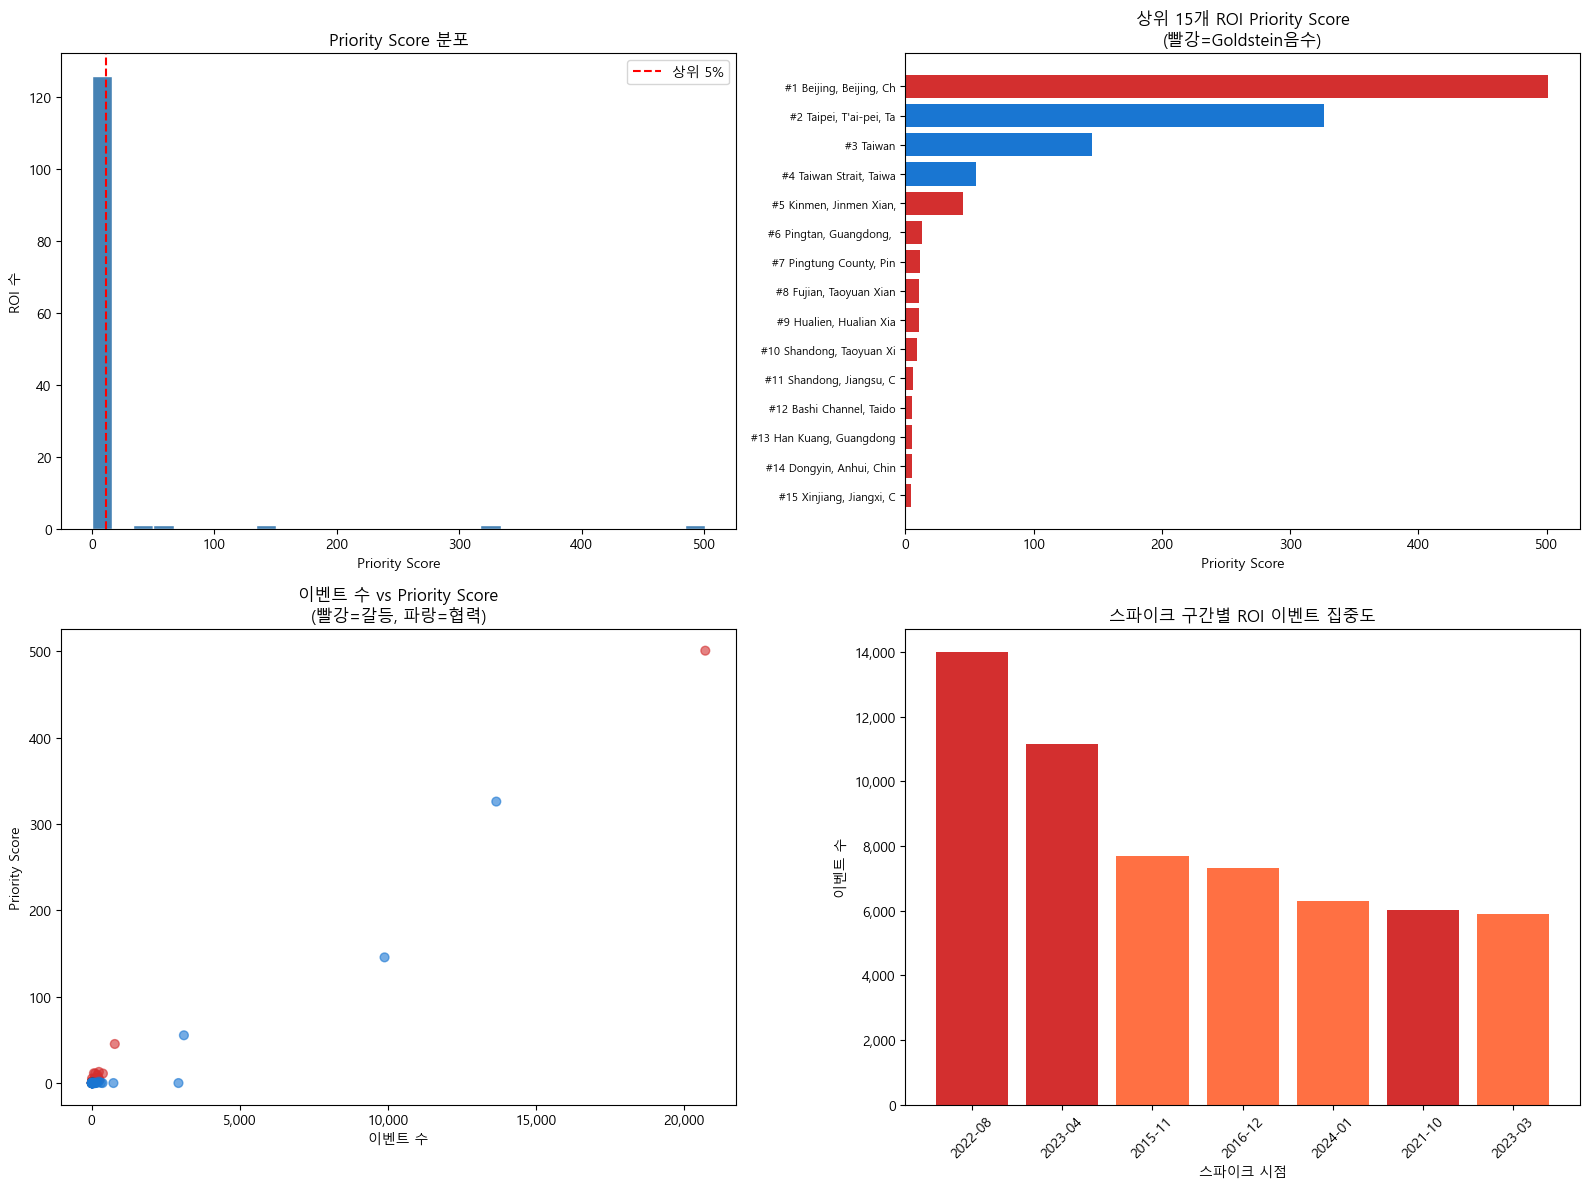

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df_roi = pd.read_parquet("data/processed/roi_clusters.parquet")
df_roi['spike_dist'] = df_roi['spike_dist'].apply(
    lambda x: eval(x) if isinstance(x, str) else x
)

# ── 1. 모호 좌표 비율 확인 (radius_km=0 = 중심점 좌표) ───────
ambiguous = (df_roi['radius_km'] == 0).sum()
precise   = (df_roi['radius_km'] >  0).sum()

print("=== ROI 좌표 품질 ===")
print(f"정밀 좌표 (radius > 0) : {precise}개  ({precise/len(df_roi)*100:.1f}%)")
print(f"모호 좌표 (radius = 0) : {ambiguous}개 ({ambiguous/len(df_roi)*100:.1f}%)")
print()

# ── 2. Priority Score 분포 ───────────────────────────────────
print("=== Priority Score 분포 ===")
print(f"최고값  : {df_roi['priority_score'].max():.1f}")
print(f"평균값  : {df_roi['priority_score'].mean():.1f}")
print(f"중앙값  : {df_roi['priority_score'].median():.1f}")
print(f"상위 5% : {df_roi['priority_score'].quantile(0.95):.1f}")
print()

# ── 3. Goldstein 음수 ROI (실질 갈등 지역) ──────────────────
df_hostile_roi = df_roi[df_roi['avg_goldstein'] < 0].sort_values('priority_score', ascending=False)
print(f"=== Goldstein 음수 ROI (실질 갈등) : {len(df_hostile_roi)}개 ===")
print(df_hostile_roi[['priority_rank','top_location',
                       'avg_goldstein','event_count',
                       'priority_score']].head(10).to_string(index=False))
print()

# ── 4. 시각화 ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 4-1. Priority Score 분포
axes[0,0].hist(df_roi['priority_score'], bins=30,
               color='steelblue', edgecolor='white')
axes[0,0].axvline(df_roi['priority_score'].quantile(0.95),
                  color='red', linestyle='--', label='상위 5%')
axes[0,0].set_title('Priority Score 분포', fontsize=12)
axes[0,0].set_xlabel('Priority Score')
axes[0,0].set_ylabel('ROI 수')
axes[0,0].legend()

# 4-2. 상위 15개 ROI 스코어 막대
top15 = df_roi.head(15)
bar_colors = ['#d32f2f' if g < 0 else '#1976d2'
              for g in top15['avg_goldstein']]
axes[0,1].barh(range(15), top15['priority_score'].values,
               color=bar_colors)
axes[0,1].set_yticks(range(15))
axes[0,1].set_yticklabels(
    [f"#{r} {n[:20]}" for r, n in
     zip(top15['priority_rank'], top15['top_location'])],
    fontsize=8
)
axes[0,1].invert_yaxis()
axes[0,1].set_title('상위 15개 ROI Priority Score\n(빨강=Goldstein음수)', fontsize=12)
axes[0,1].set_xlabel('Priority Score')

# 4-3. 이벤트 수 vs Priority Score 산점도
scatter_colors = ['#d32f2f' if g < 0 else '#1976d2'
                  for g in df_roi['avg_goldstein']]
axes[1,0].scatter(df_roi['event_count'], df_roi['priority_score'],
                  c=scatter_colors, alpha=0.6, s=40)
axes[1,0].set_title('이벤트 수 vs Priority Score\n(빨강=갈등, 파랑=협력)', fontsize=12)
axes[1,0].set_xlabel('이벤트 수')
axes[1,0].set_ylabel('Priority Score')
axes[1,0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# 4-4. 스파이크 구간별 ROI 집중도
spike_roi_counts = {}
for _, row in df_roi.iterrows():
    for month, count in row['spike_dist'].items():
        spike_roi_counts[month] = spike_roi_counts.get(month, 0) + count

spike_series = pd.Series(spike_roi_counts).sort_values(ascending=False)
bar_c2 = ['#d32f2f' if m in ['2022-08','2023-04','2021-10']
           else '#ff7043' for m in spike_series.index]
axes[1,1].bar(spike_series.index, spike_series.values, color=bar_c2)
axes[1,1].set_title('스파이크 구간별 ROI 이벤트 집중도', fontsize=12)
axes[1,1].set_xlabel('스파이크 시점')
axes[1,1].set_ylabel('이벤트 수')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout()
plt.savefig("data/eda_roi_analysis.png", dpi=150, bbox_inches='tight')
plt.show()


#### EDA에서 확인된 실제 구현 시 반영사항

EDA 발견                          →  실제 구현 반영사항

─────────────────────────────────────────────────────────

radius_km = 0 ROI 다수 존재       →  PiP + Geocoding 보정 필수

GDELT 지명 오류 (성/도 불일치)    →  교차검증 로직 필요

베이징 이벤트 수 압도적           →  정치 이벤트 vs 군사 이벤트 분리 필요

진먼/바시해협 Goldstein 음수      →  대만해협 Level 1 구역 별도 가중치 확인

상위 2개가 전체 스코어 독점       →  정규화(Min-Max/Log) 적용 필요

#### EDA 최종 진단
**발견된 3가지 핵심 문제**

① 모호 좌표 83.2% — 가장 심각

- 131개 ROI 중 109개가 radius = 0

    → 국가/지역 중심점 좌표로 클러스터링된 것

    → 위성 타겟팅에 실제 사용 불가능한 ROI가 83%

    → PiP + Geocoding 보정이 선택이 아닌 필수임을 증명

② Priority Score 편중 심각
- 최고값 500.9 vs 중앙값 0.1

    → 베이징(500.9), 타이베이(326.1) 두 곳이 전체를 독점

    → 나머지 129개 ROI는 사실상 변별력 없음

    → Log 정규화 필수

③ Goldstein 음수 ROI 55개 중 실질 의미 있는 곳은 소수

- 진먼(-0.455, 781건)  → ✅ 실제 군사 긴장 지역

- 바시해협(-0.790)     → ✅ 전략적 해협

- 한광(-4.805, 102건)  → ⚠️ 이벤트 수 너무 적어 신뢰도 낮음
    
- Shandong/Fujian 지명 오류 다수 → ⚠️ GDELT 지명 오류

#### EDA 전체 요약 리포트 저장

In [ ]:
import json
from datetime import datetime

eda_summary = {
    "생성일시": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "프로젝트": "양안관계 OSINT-GEOINT 의사결정 지원 시스템",

    "데이터_기본정보": {
        "총_이벤트_수": 492452,
        "기간": "2013-04-01 ~ 2026-04-26",
        "결측률_최대": "0.03% (ActionGeo_FullName)",
        "좌표_보유율": "100.0%"
    },

    "스파이크_탐지": {
        "월평균_이벤트": 3137,
        "표준편차": 2104,
        "임계값_2sigma": 7345,
        "임계값_3sigma": 9449,
        "스파이크_7개월": {
            "2022-08": {"건수": 18068, "사건": "펠로시 방문+군사훈련", "등급": "3σ초과"},
            "2023-04": {"건수": 13824, "사건": "연합리검-2023 훈련",   "등급": "3σ초과"},
            "2015-11": {"건수": 10644, "사건": "시진핑-마잉주 회담",   "등급": "3σ초과"},
            "2016-12": {"건수": 10371, "사건": "트럼프-차이잉원 통화", "등급": "3σ초과"},
            "2024-01": {"건수":  7737, "사건": "대만 총통선거",        "등급": "2σ~3σ"},
            "2021-10": {"건수":  7444, "사건": "중국 ADIZ 대규모 진입","등급": "2σ~3σ"},
            "2023-03": {"건수":  7410, "사건": "차이잉원 방미 압박",   "등급": "2σ~3σ"}
        }
    },

    "CAMEO_분석": {
        "적대_이벤트_비율_전체":   "16.8%",
        "적대_이벤트_비율_스파이크": "높음",
        "스파이크_시_폭증_이벤트": {
            "강압(15)": "+75%",
            "부상(19)": "+25%",
            "위협(13)": "+23%",
            "무력공격(16)": "+15%"
        },
        "스파이크_시_감소_이벤트": {
            "사이버(17)": "-45%"
        }
    },

    "Goldstein_분석": {
        "전체_평균":    0.373,
        "스파이크_평균": 0.158,
        "평시_평균":    0.412,
        "구조적_전환점": "2020~2022년 음수 전환 (협력→갈등 패러다임 변화)",
        "스파이크_분류": {
            "갈등형": ["2021-10(-0.6)", "2022-08(-0.4)", "2023-04(-0.4)"],
            "협력형": ["2015-11(+2.1)", "2016-12(+0.7)", "2023-03(+0.9)"]
        }
    },

    "ROI_분석": {
        "총_ROI_수": 131,
        "정밀_좌표_ROI": "22개 (16.8%)",
        "모호_좌표_ROI": "109개 (83.2%)",
        "Priority_Score": {
            "최고": 500.9,
            "평균": 9.1,
            "중앙값": 0.1,
            "상위5%": 11.2
        },
        "Goldstein_음수_ROI": 55,
        "실질_군사긴장_ROI": ["진먼", "바시해협", "핑탄", "핑둥", "화롄"]
    },

    "실제_구현_반영사항": {
        "필수": [
            "PiP + Geocoding 보정 (모호 좌표 83% 해결)",
            "Priority Score Log 정규화 (편중 해결)",
            "GDELT 지명 오류 교차검증 (Shandong/Fujian 오류)",
            "이벤트 수 최소 임계값 설정 (100건 미만 ROI 필터링)"
        ],
        "권장": [
            "정치 이벤트 vs 군사 이벤트 분리 (베이징 독점 해소)",
            "갈등형 스파이크에만 위성 트리거 발동",
            "Level 1 대만해협 구역 별도 가중치 상향"
        ]
    },

    "위성_촬영_1순위_타겟": [
        "베이징 (정치 의사결정)",
        "타이베이 (대만 대응)",
        "진먼 (대만해협 최전선)",
        "바시해협 (전략 해협)",
        "핑탄/푸젠 (중국 군사 집결지)"
    ]
}

with open("data/processed/eda_final_summary.json", "w", encoding="utf-8") as f:
    json.dump(eda_summary, f, ensure_ascii=False, indent=2)

print("EDA 최종 요약 저장 완료 → data/processed/eda_final_summary.json")

EDA 최종 요약 저장 완료 → data/processed/eda_final_summary.json


#### Phase 5. 지리 데이터 품질 점검 : 위성 타겟팅 가능 여부 판단

In [24]:
# ── 5-1. 좌표 결측률 확인 ────────────────────────────────────
geo_cols = ['ActionGeo_Lat', 'ActionGeo_Long']
geo_valid = df.dropna(subset=geo_cols)
geo_invalid = df[df[geo_cols].isnull().any(axis=1)]

print("=== 지리 데이터 품질 ===")
print(f"좌표 있음  : {len(geo_valid):,}건 ({len(geo_valid)/len(df)*100:.1f}%)")
print(f"좌표 없음  : {len(geo_invalid):,}건 ({len(geo_invalid)/len(df)*100:.1f}%)")
print()

# ── 5-2. 좌표 범위 이상치 확인 ──────────────────────────────
# 대만해협 중심 범위: 위도 20~30°N, 경도 115~125°E
in_range = geo_valid[
    (geo_valid['ActionGeo_Lat'].between(15, 40)) &
    (geo_valid['ActionGeo_Long'].between(105, 135))
]
print(f"대만해협 인근 좌표: {len(in_range):,}건 ({len(in_range)/len(geo_valid)*100:.1f}%)")
print(f"범위 밖 좌표      : {len(geo_valid) - len(in_range):,}건")
print()
print("=== ActionGeo_FullName 상위 20개 지역 ===")
print(df['ActionGeo_FullName'].value_counts().head(20))

=== 지리 데이터 품질 ===
좌표 있음  : 493,394건 (100.0%)
좌표 없음  : 48건 (0.0%)

대만해협 인근 좌표: 434,400건 (88.0%)
범위 밖 좌표      : 58,994건

=== ActionGeo_FullName 상위 20개 지역 ===
ActionGeo_FullName
Beijing, Beijing, China                            122271
Taipei, T'ai-pei, Taiwan                            93078
Taiwan                                              59721
China                                               37059
Republic Of China, Taiwan (general), Taiwan         20737
Taiwan Strait, Taiwan (general), Taiwan             15020
Washington, District of Columbia, United States      7454
Shanghai, Shanghai, China                            6602
Kinmen, Jinmen Xian, Taiwan                          5191
Hong Kong                                            4294
United States                                        3928
Japan                                                2607
South China Sea, Brunei (general), Brunei            2554
Fujian, Taoyuan Xian, Taiwan                         2432
Xiamen, Fujia